# Proyecto Final — Modelos Econométricos

## Análisis Econométrico Integral del Mercado del Aguacate Mexicano:
## Producción, Precio y Exportación

**Escuela Superior de Cómputo — Instituto Politécnico Nacional**  
Semestre 2026-2

---

**Integrantes:**
* Barranco Tamayo Santiago Federico
* Cortes Moreno Mauricio Hamabiel
* Soria Martinez Jesús Armando

---

### Fuentes de datos reales utilizadas
| Dataset | Fuente | Período | Observaciones |
|---|---|---|---|
| Producción agrícola | SIAP-SADER | 2003–2023 | 12,819 registros municipales |
| Precios al consumidor | PROFECO | 2015–2024 | 151,510 registros por tienda |
| Exportaciones detalladas | INEGI-COMEXT | 2003–2023 | Por país destino |
| Exportaciones mensuales | Banxico | 1993–2023 | Serie mensual en USD miles |

### Pregunta de investigación
> ¿Qué factores determinan el precio del aguacate mexicano y es posible pronosticarlo mediante modelos econométricos?

### Hipótesis
1. La producción tiene un efecto **negativo** sobre el precio (ley de oferta).
2. El crecimiento exportador **presiona al alza** los precios domésticos.
3. Es posible **pronosticar** el precio al consumidor mediante modelos ARIMA.

 Sube los 4 archivos CSV a la sesión de Colab antes de ejecutar:
> `siap_produccion.csv`, `profeco_precios.csv`, `inegi_exportaciones.csv`, `banxico_exportaciones.csv`


## 0. Importaciones y configuración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import jarque_bera, shapiro, norm
import statsmodels.api as sm
from statsmodels.formula.api import ols, logit, probit
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, acorr_breusch_godfrey
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({'figure.figsize': (12, 5), 'figure.dpi': 120, 'font.size': 11})

## 1. Carga y preparación de datos reales

### 1.1 SIAP — Producción agrícola (2003–2023)

In [ ]:
df_siap = pd.read_csv('siap_produccion.csv')
print(f"Shape: {df_siap.shape}  |  Años: {df_siap['Anio'].min()}–{df_siap['Anio'].max()}")
df_siap[['Anio','Nomestado','Volumenproduccion','Cosechada','Precio','Rendimiento']].head(3)


Shape: (12819, 24)  |  Años: 2003–2023


,Anio,Nomestado,Volumenproduccion,Cosechada,Precio,Rendimiento
0,2003,Aguascalientes,19.00,7.0,5421.05,2.71
1,2003,Baja California,0.00,0.0,0.00,0.00
2,2003,Baja California,46.53,11.0,6500.00,4.23


### 1.2 PROFECO — Precios al consumidor (2015–2024)

In [ ]:
df_prof = pd.read_csv('profeco_precios.csv', parse_dates=['fecha_registro'])
print(f"Shape: {df_prof.shape}  |  Período: {df_prof['fecha_registro'].min().date()} – {df_prof['fecha_registro'].max().date()}")
df_prof.head(3)


Shape: (151510, 12)  |  Período: 2015-01-02 – 2024-07-31


,producto,presentacion,precio,fecha_registro,cadena_comercial,giro,nombre_comercial,direccion,estado,municipio,latitud,longitud
0,AGUACATE,1 KG. HASS,19.9,2015-01-02,MERCADO SORIANA,SUPERMERCADO / TIENDA DE AUTOSERVICIO,MERCADO SORIANA SUCURSAL LA ASUNCION,"SIGLO XXI 2302, ENTRE MATIAS A. DE LA MOTA Y F...",AGUASCALIENTES,AGUASCALIENTES,21.926644,-102.265892
1,AGUACATE,1 KG. HASS,27.9,2015-01-02,HIPERMERCADO SORIANA,SUPERMERCADO / TIENDA DE AUTOSERVICIO,SORIANA HIPER SUCURSAL MISION,"REFORMA 1122, ENTRE CALLE ONCE Y OLIVOS, COL. ...",BAJA CALIFORNIA,ENSENADA,31.870929,-116.608614
2,AGUACATE,1 KG. HASS,26.9,2015-01-02,CALIMAX,SUPERMERCADO / TIENDA DE AUTOSERVICIO,CALIMAX SUCURSAL ZARAGOZA,"GRAL. IGNACIO ZARAGOZA 935, ESQ. CALLE K, COL...",BAJA CALIFORNIA,MEXICALI,32.661897,-115.457885


### 1.3 INEGI — Exportaciones por país (2003–2023)

In [ ]:
df_inegi = pd.read_csv('inegi_exportaciones.csv')
print(f"Shape: {df_inegi.shape}  |  Años: {sorted(df_inegi['ANIO'].unique())}")
df_inegi.head(3)


Shape: (1404, 11)  |  Años: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


,TIPO,ANIO,MES,TARIFA,UMED,PAIS_O_D,CANTIDAD,VAL_MNX,VAL_USD,ESTATUS_CIFRA,ESTATUS
0,Exportaciones,2003,01-12,80440,NaN,NaN,NaN,2.122636e+09,195062994.0,Disponible,Cifras Definitivas.
1,Exportaciones,2003,01-12,80440,NaN,BEL,NaN,3.544260e+05,32500.0,Disponible,Cifras Definitivas.
2,Exportaciones,2003,01-12,80440,NaN,CAN,NaN,2.034109e+08,18849631.0,Disponible,Cifras Definitivas.


### 1.4 Banxico — Exportaciones mensuales (1993–2023)

In [ ]:
df_ban = pd.read_csv('banxico_exportaciones.csv')
df_ban['fecha'] = pd.to_datetime(df_ban['Fecha'], format='%m/%d/%Y')
df_ban['anio']  = df_ban['fecha'].dt.year
df_ban['mes']   = df_ban['fecha'].dt.month
print(f"Shape: {df_ban.shape}  |  Período: {df_ban['fecha'].min().date()} – {df_ban['fecha'].max().date()}")
df_ban.head(3)


Shape: (378, 5)  |  Período: 1993-01-01 – 2024-06-01


,Fecha,USD_miles,fecha,anio,mes
0,01/01/1993,1197,1993-01-01,1993,1
1,02/01/1993,1297,1993-02-01,1993,2
2,03/01/1993,1033,1993-03-01,1993,3


### 1.5 Construcción de los datasets de análisis

Se construyen dos conjuntos:

| Dataset | Fuente principal | Uso |
|---|---|---|
| `df_ts` — serie temporal mensual | PROFECO + Banxico + SIAP + INEGI | ARIMA, rezagos, ajuste parcial |
| `df_cs` — corte transversal estado-año | SIAP por estado | Logit/Probit, dummies |


In [ ]:
# ── Producción anual nacional (SIAP) ─────────────────────────────────────────
siap_anual = (df_siap.groupby('Anio')
              .agg(produccion_miles_ton=('Volumenproduccion', lambda x: x.sum()/1000),
                   superficie_miles_ha =('Cosechada', lambda x: x.sum()/1000),
                   precio_productor_ton=('Precio','mean'),
                   valor_produccion_mdp=('Valorproduccion', lambda x: x.sum()/1e6))
              .round(2).reset_index())
siap_anual.columns = ['anio','produccion_miles_ton','superficie_miles_ha',
                      'precio_productor_ton','valor_produccion_mdp']

# ── Precio mensual al consumidor (PROFECO) ────────────────────────────────────
df_prof['anio'] = df_prof['fecha_registro'].dt.year
df_prof['mes']  = df_prof['fecha_registro'].dt.month
prof_mes = (df_prof.groupby(['anio','mes'])['precio']
            .mean().round(2).reset_index()
            .rename(columns={'precio':'precio_consumidor_kg'}))

# ── Exportaciones anuales totales (INEGI) ─────────────────────────────────────
inegi_tot = (df_inegi[df_inegi['PAIS_O_D'].isna()]
             .groupby('ANIO')['VAL_USD'].sum()
             .div(1e6).round(2).reset_index()
             .rename(columns={'ANIO':'anio','VAL_USD':'export_mill_usd'}))

# ── Serie temporal mensual 2015–2023 ─────────────────────────────────────────
ban_mes = df_ban[['fecha','anio','mes','USD_miles']].rename(columns={'USD_miles':'export_usd_miles'})
df_ts   = ban_mes[(ban_mes['anio'] >= 2015) & (ban_mes['anio'] <= 2023)].copy()
df_ts   = df_ts.merge(prof_mes, on=['anio','mes'], how='left')
df_ts   = df_ts.merge(siap_anual, on='anio', how='left')
df_ts   = df_ts.merge(inegi_tot, on='anio', how='left')
df_ts   = df_ts.sort_values('fecha').reset_index(drop=True)
df_ts['temporada_alta'] = df_ts['mes'].isin([1,2,3,10,11,12]).astype(int)
df_ts['periodo_covid']  = ((df_ts['fecha'] >= '2020-03-01') & (df_ts['fecha'] <= '2021-06-01')).astype(int)

print(f"Serie temporal: {df_ts.shape}  |  {df_ts['fecha'].min().date()} – {df_ts['fecha'].max().date()}")
df_ts.head(4)


Serie temporal: (108, 12)  |  2015-01-01 – 2023-12-01


,fecha,anio,mes,export_usd_miles,precio_consumidor_kg,produccion_miles_ton,superficie_miles_ha,precio_productor_ton,valor_produccion_mdp,export_mill_usd,temporada_alta,periodo_covid
0,2015-01-01,2015,1,154987,26.81,1644.23,166.94,10328.42,22548.79,3264.94,1,0
1,2015-02-01,2015,2,124995,28.32,1644.23,166.94,10328.42,22548.79,3264.94,1,0
2,2015-03-01,2015,3,161894,31.54,1644.23,166.94,10328.42,22548.79,3264.94,1,0
3,2015-04-01,2015,4,141797,37.11,1644.23,166.94,10328.42,22548.79,3264.94,0,0


In [ ]:
# ── Corte transversal: SIAP por estado-año (2010–2023) ───────────────────────
df_cs = (df_siap.groupby(['Anio','Nomestado'])
         .agg(produccion_ton   =('Volumenproduccion','sum'),
              superficie_ha    =('Cosechada','sum'),
              precio_productor =('Precio','mean'),
              valor_mdp        =('Valorproduccion', lambda x: x.sum()/1e6))
         .round(2).reset_index())
df_cs.columns = ['anio','estado','produccion_ton','superficie_ha','precio_productor_ton','valor_mdp']
df_cs['rendimiento_ton_ha'] = (df_cs['produccion_ton'] / df_cs['superficie_ha'].replace(0,np.nan)).round(2)
df_cs['es_michoacan']  = (df_cs['estado'] == 'Michoacán de Ocampo').astype(int)
df_cs['es_exportador'] = (df_cs['produccion_ton'] > 10000).astype(int)
df_cs['precio_alto']   = (df_cs['precio_productor_ton'] >
                           df_cs.groupby('anio')['precio_productor_ton'].transform('median')).astype(int)
df_cs = df_cs[df_cs['anio'] >= 2010].reset_index(drop=True)

print(f"Corte transversal: {df_cs.shape}")
df_cs.head(4)


Corte transversal: (389, 10)


,anio,estado,produccion_ton,superficie_ha,precio_productor_ton,valor_mdp,rendimiento_ton_ha,es_michoacan,es_exportador,precio_alto
0,2010,Aguascalientes,204.00,17.0,15000.00,3.06,12.00,0,0,1
1,2010,Baja California,61.50,24.0,11000.00,0.72,2.56,0,0,1
2,2010,Baja California Sur,775.00,110.0,11883.33,7.53,7.05,0,0,1
3,2010,Campeche,473.81,64.0,3780.00,1.93,7.40,0,0,0


---
## Etapa 1 — Estadística Descriptiva

### 1.1 Medidas de tendencia central

In [ ]:
vars_d = ['precio_consumidor_kg','export_usd_miles','produccion_miles_ton',
          'superficie_miles_ha','precio_productor_ton']
pd.DataFrame({
    'Media':   df_ts[vars_d].mean(),
    'Mediana': df_ts[vars_d].median(),
    'Moda':    df_ts[vars_d].apply(lambda x: x.mode()[0]),
}).round(2)


,Media,Mediana,Moda
precio_consumidor_kg,52.63,52.76,44.57
export_usd_miles,225146.86,224187.50,118187.00
produccion_miles_ton,2266.65,2300.89,1644.23
superficie_miles_ha,210.99,215.94,166.94
precio_productor_ton,15019.49,16019.98,10328.42


### 1.2 Medidas de dispersión

In [ ]:
pd.DataFrame({
    'Varianza':      df_ts[vars_d].var(),
    'Desv. Std':     df_ts[vars_d].std(),
    'Coef. Var (%)': df_ts[vars_d].std() / df_ts[vars_d].mean() * 100,
}).round(2)


,Varianza,Desv. Std,Coef. Var (%)
precio_consumidor_kg,2.519100e+02,15.87,30.16
export_usd_miles,3.880617e+09,62294.59,27.67
produccion_miles_ton,1.363172e+05,369.21,16.29
superficie_miles_ha,7.013900e+02,26.48,12.55
precio_productor_ton,9.548339e+06,3090.04,20.57


### 1.3 Medidas de forma

In [ ]:
pd.DataFrame({
    'Curtosis':  df_ts[vars_d].kurtosis(),
    'Asimetría': df_ts[vars_d].skew(),
}).round(4)


,Curtosis,Asimetría
precio_consumidor_kg,0.7713,0.5796
export_usd_miles,-0.0676,0.4250
produccion_miles_ton,-0.3423,0.1644
superficie_miles_ha,-1.0196,-0.1654
precio_productor_ton,-1.1113,-0.0251


### 1.4 Histogramas (5 obligatorios)

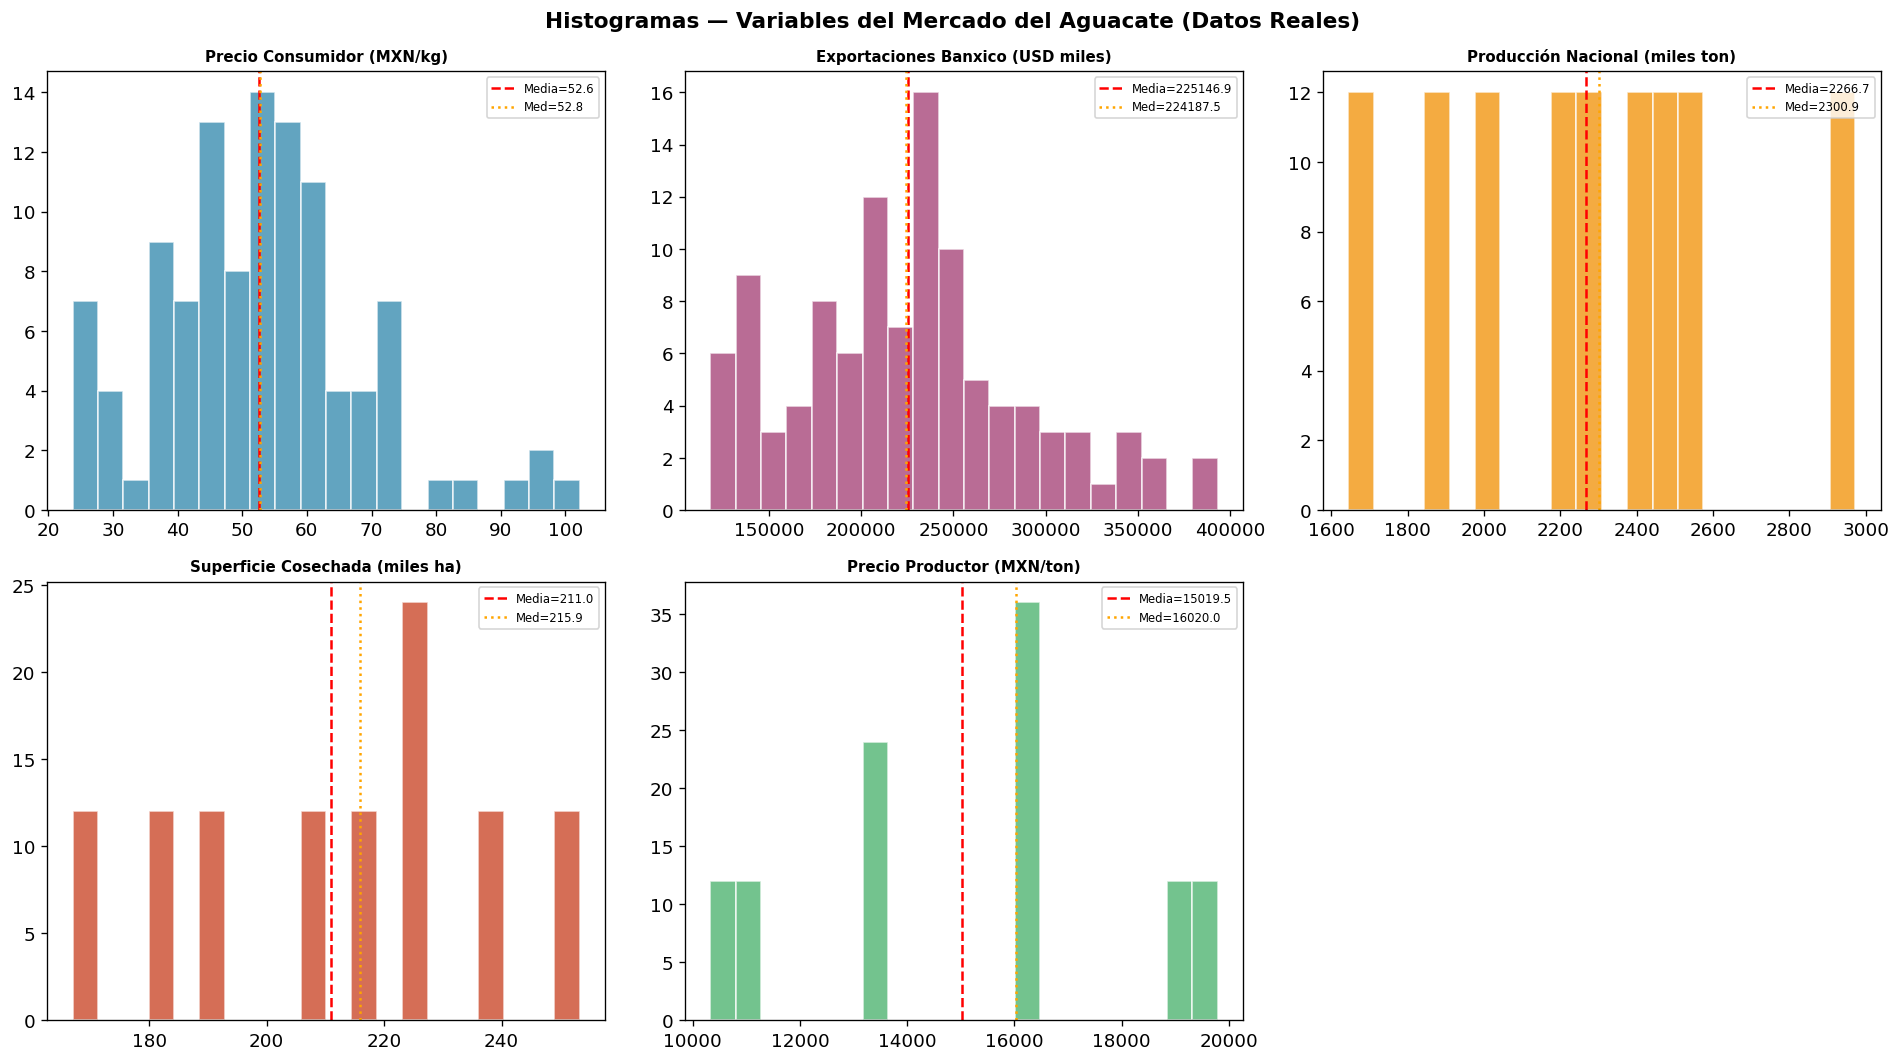

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
hvars  = ['precio_consumidor_kg','export_usd_miles','produccion_miles_ton',
          'superficie_miles_ha','precio_productor_ton']
titulos = ['Precio Consumidor (MXN/kg)','Exportaciones Banxico (USD miles)',
           'Producción Nacional (miles ton)','Superficie Cosechada (miles ha)',
           'Precio Productor (MXN/ton)']
cols   = ['#2E86AB','#A23B72','#F18F01','#C73E1D','#44AF69']

for ax, v, t, c in zip(axes.flat, hvars, titulos, cols):
    ax.hist(df_ts[v].dropna(), bins=20, color=c, alpha=0.75, edgecolor='white')
    ax.axvline(df_ts[v].mean(),   color='red',    ls='--', lw=1.5, label=f'Media={df_ts[v].mean():.1f}')
    ax.axvline(df_ts[v].median(), color='orange', ls=':',  lw=1.5, label=f'Med={df_ts[v].median():.1f}')
    ax.set_title(t, fontweight='bold', fontsize=9); ax.legend(fontsize=7)

axes[1,2].axis('off')
plt.suptitle('Histogramas — Variables del Mercado del Aguacate (Datos Reales)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### 1.5 Diagramas de caja (2 obligatorios)

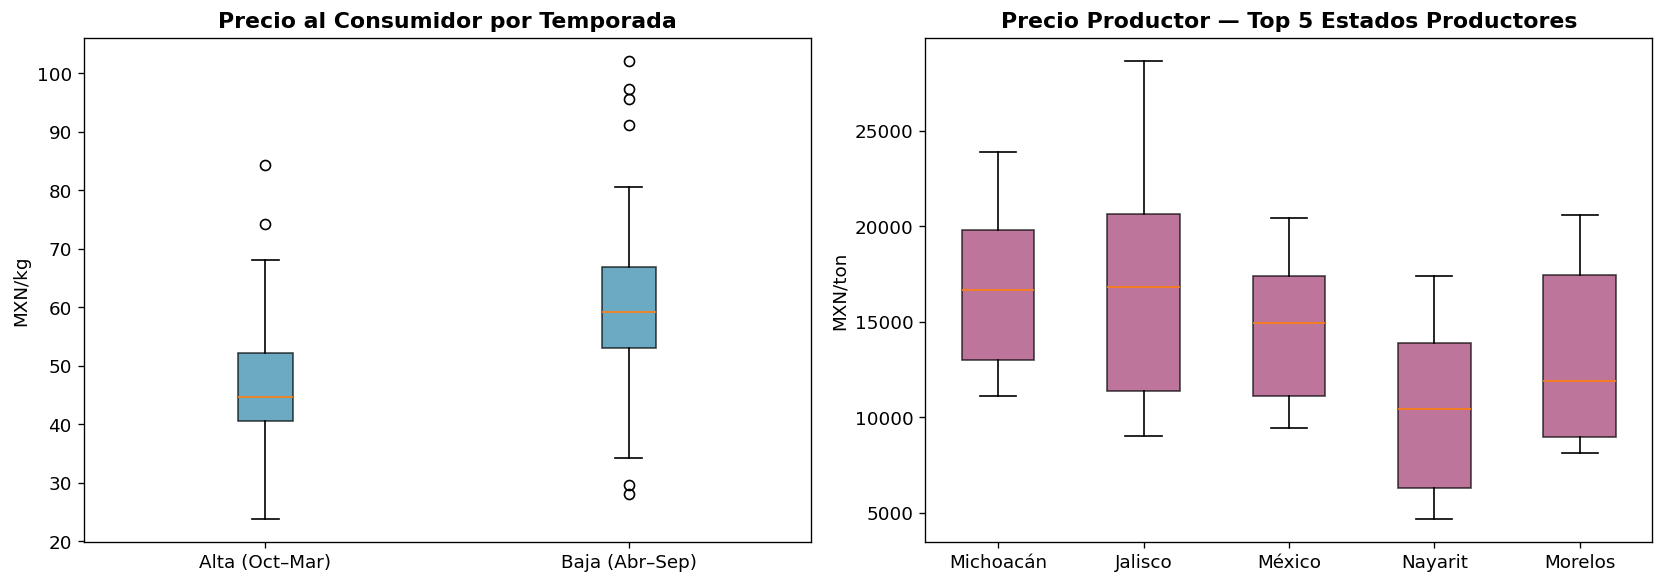

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([df_ts[df_ts['temporada_alta']==1]['precio_consumidor_kg'].dropna(),
                 df_ts[df_ts['temporada_alta']==0]['precio_consumidor_kg'].dropna()],
                labels=['Alta (Oct–Mar)','Baja (Abr–Sep)'],
                patch_artist=True, boxprops=dict(facecolor='#2E86AB', alpha=0.7))
axes[0].set_title('Precio al Consumidor por Temporada', fontweight='bold')
axes[0].set_ylabel('MXN/kg')

top5 = df_cs.groupby('estado')['produccion_ton'].mean().nlargest(5).index
data_box = [df_cs[df_cs['estado']==e]['precio_productor_ton'].dropna() for e in top5]
axes[1].boxplot(data_box, labels=[e.split()[0] for e in top5],
                patch_artist=True, boxprops=dict(facecolor='#A23B72', alpha=0.7))
axes[1].set_title('Precio Productor — Top 5 Estados Productores', fontweight='bold')
axes[1].set_ylabel('MXN/ton')
plt.tight_layout(); plt.show()


### 1.6 Diagramas de dispersión (2 obligatorios)

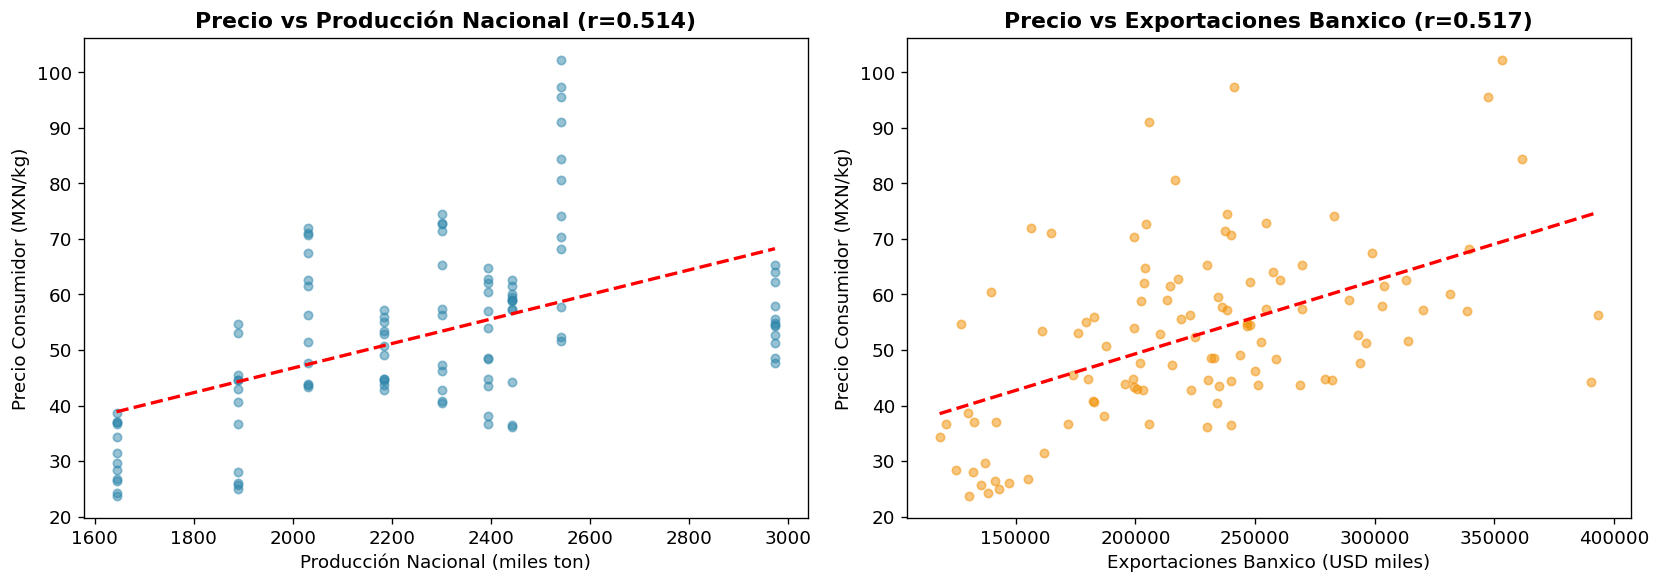

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, xv, col, xl in zip(axes,
    ['produccion_miles_ton','export_usd_miles'],
    ['#2E86AB','#F18F01'],
    ['Producción Nacional (miles ton)','Exportaciones Banxico (USD miles)']):
    sub = df_ts[['precio_consumidor_kg', xv]].dropna()
    ax.scatter(sub[xv], sub['precio_consumidor_kg'], alpha=0.5, s=25, c=col)
    z = np.polyfit(sub[xv], sub['precio_consumidor_kg'], 1)
    xl2 = np.linspace(sub[xv].min(), sub[xv].max(), 100)
    ax.plot(xl2, np.poly1d(z)(xl2), 'r--', lw=2)
    r = sub[xv].corr(sub['precio_consumidor_kg'])
    ax.set_title(f'Precio vs {xl.split("(")[0].strip()} (r={r:.3f})', fontweight='bold')
    ax.set_xlabel(xl); ax.set_ylabel('Precio Consumidor (MXN/kg)')

plt.tight_layout(); plt.show()


### 1.7 Matriz de correlación (obligatoria)

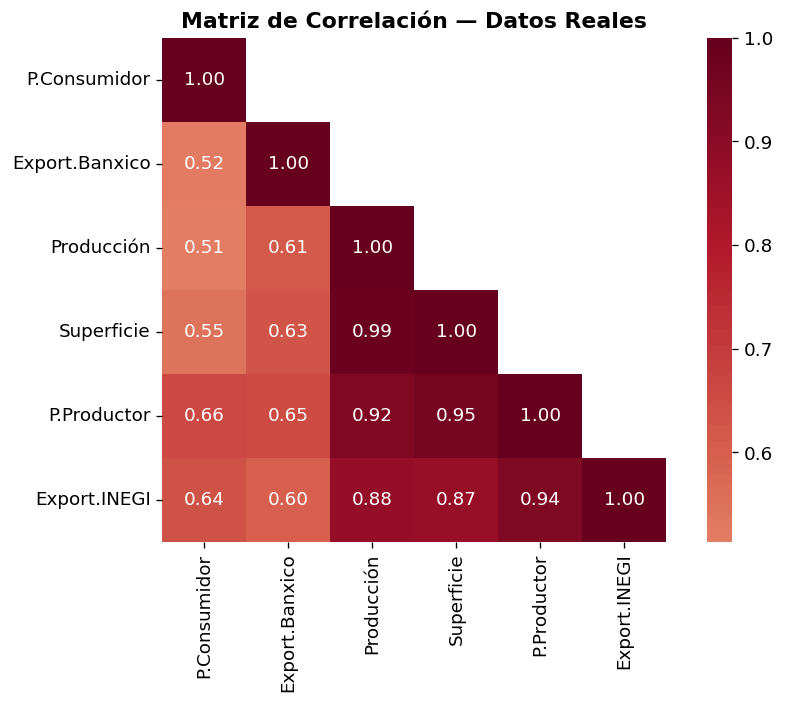

In [ ]:
cm_vars  = ['precio_consumidor_kg','export_usd_miles','produccion_miles_ton',
            'superficie_miles_ha','precio_productor_ton','export_mill_usd']
cm_labs  = ['P.Consumidor','Export.Banxico','Producción','Superficie','P.Productor','Export.INEGI']
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones((len(cm_vars),)*2, dtype=bool), k=1)
sns.heatmap(df_ts[cm_vars].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=cm_labs, yticklabels=cm_labs, mask=mask, ax=ax, square=True)
ax.set_title('Matriz de Correlación — Datos Reales', fontweight='bold')
plt.tight_layout(); plt.show()


---
## Etapa 2 — Regresión Lineal Simple

**Modelo:** Precio_consumidor = β₀ + β₁·Producción + u

In [ ]:
sub2 = df_ts[['precio_consumidor_kg','produccion_miles_ton']].dropna()
X_s  = sm.add_constant(sub2['produccion_miles_ton'])
mod_s = sm.OLS(sub2['precio_consumidor_kg'], X_s).fit()
print(mod_s.summary())


                             OLS Regression Results                             
Dep. Variable:     precio_consumidor_kg   R-squared:                       0.264
Model:                              OLS   Adj. R-squared:                  0.257
Method:                   Least Squares   F-statistic:                     38.03
Date:                  Mon, 22 Jun 2026   Prob (F-statistic):           1.29e-08
Time:                          03:39:33   Log-Likelihood:                -434.76
No. Observations:                   108   AIC:                             873.5
Df Residuals:                       106   BIC:                             878.9
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const       

In [ ]:
b0, b1 = mod_s.params
pv1    = mod_s.pvalues.iloc[1]
print(f"β₀ = {b0:.4f}  β₁ = {b1:.4f}")
print(f"R² = {mod_s.rsquared:.4f}  →  la producción explica el {mod_s.rsquared*100:.1f}% de la variación del precio")
print(f"p-value β₁ = {pv1:.4f}  {' Significativo al 5%' if pv1<0.05 else ' No significativo'}")
print(f"\nIC 95%:")
print(mod_s.conf_int())


β₀ = 2.5583  β₁ = 0.0221
R² = 0.2640  →  la producción explica el 26.4% de la variación del precio
p-value β₁ = 0.0000  ✅ Significativo al 5%

IC 95%:
                              0          1
const                -13.748939  18.865616
produccion_miles_ton   0.014987   0.029190


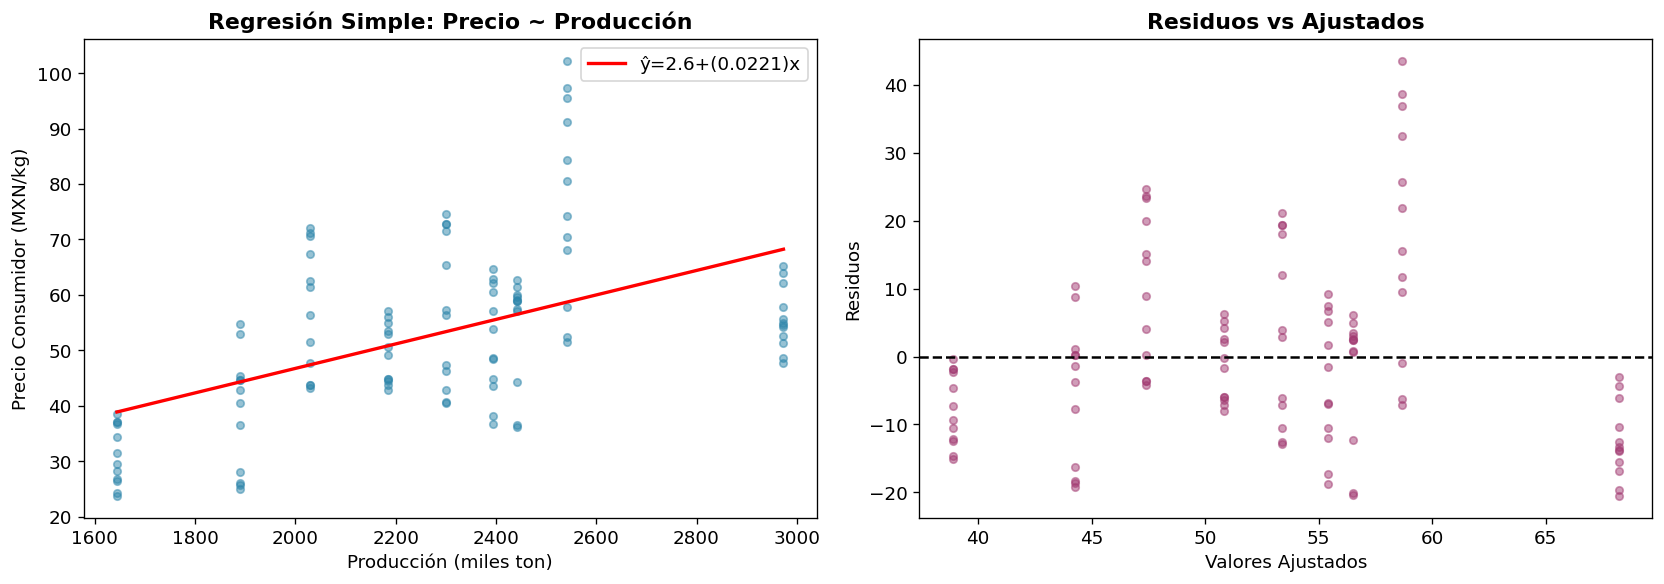

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
xl = np.linspace(sub2['produccion_miles_ton'].min(), sub2['produccion_miles_ton'].max(), 200)
axes[0].scatter(sub2['produccion_miles_ton'], sub2['precio_consumidor_kg'], alpha=0.5, s=20, c='#2E86AB')
axes[0].plot(xl, b0+b1*xl, 'r-', lw=2, label=f'ŷ={b0:.1f}+({b1:.4f})x')
axes[0].set_xlabel('Producción (miles ton)'); axes[0].set_ylabel('Precio Consumidor (MXN/kg)')
axes[0].set_title('Regresión Simple: Precio ~ Producción', fontweight='bold'); axes[0].legend()

axes[1].scatter(mod_s.fittedvalues, mod_s.resid, alpha=0.5, s=20, c='#A23B72')
axes[1].axhline(0, color='k', ls='--')
axes[1].set_xlabel('Valores Ajustados'); axes[1].set_ylabel('Residuos')
axes[1].set_title('Residuos vs Ajustados', fontweight='bold')
plt.tight_layout(); plt.show()


---
## Etapa 3 — Regresión Lineal Múltiple

In [ ]:
X_vars = ['produccion_miles_ton','export_usd_miles','precio_productor_ton',
          'export_mill_usd','superficie_miles_ha']
sub3   = df_ts[['precio_consumidor_kg'] + X_vars].dropna()
X_m    = sm.add_constant(sub3[X_vars])
mod_m  = sm.OLS(sub3['precio_consumidor_kg'], X_m).fit()
print(mod_m.summary())


                             OLS Regression Results                             
Dep. Variable:     precio_consumidor_kg   R-squared:                       0.522
Model:                              OLS   Adj. R-squared:                  0.499
Method:                   Least Squares   F-statistic:                     22.29
Date:                  Mon, 22 Jun 2026   Prob (F-statistic):           4.87e-15
Time:                          03:39:35   Log-Likelihood:                -411.44
No. Observations:                   108   AIC:                             834.9
Df Residuals:                       102   BIC:                             851.0
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const       

In [ ]:
print(f"R²={mod_m.rsquared:.4f}  R²adj={mod_m.rsquared_adj:.4f}  F={mod_m.fvalue:.2f}(p={mod_m.f_pvalue:.2e})")
resid  = mod_m.resid
fitted = mod_m.fittedvalues


R²=0.5221  R²adj=0.4987  F=22.29(p=4.87e-15)


---
## Etapa 4 — Variables Dummy

**Dummies incluidas:** `temporada_alta` (Oct–Mar) y `periodo_covid` (Mar 2020–Jun 2021)

In [ ]:
X_dv  = ['produccion_miles_ton','export_usd_miles','precio_productor_ton',
          'temporada_alta','periodo_covid']
sub4  = df_ts[['precio_consumidor_kg'] + X_dv].dropna()
X_d   = sm.add_constant(sub4[X_dv])
mod_d = sm.OLS(sub4['precio_consumidor_kg'], X_d).fit()
print(mod_d.summary())


                             OLS Regression Results                             
Dep. Variable:     precio_consumidor_kg   R-squared:                       0.754
Model:                              OLS   Adj. R-squared:                  0.742
Method:                   Least Squares   F-statistic:                     62.47
Date:                  Mon, 22 Jun 2026   Prob (F-statistic):           1.68e-29
Time:                          03:39:36   Log-Likelihood:                -375.62
No. Observations:                   108   AIC:                             763.2
Df Residuals:                       102   BIC:                             779.3
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const       

In [ ]:
for dummy in ['temporada_alta','periodo_covid']:
    b  = mod_d.params[dummy]; pv = mod_d.pvalues[dummy]
    print(f"{dummy}: β={b:.2f}  p={pv:.4f}")
    print(f"  → El precio es {abs(b):.2f} MXN/kg {'MAYOR' if b>0 else 'MENOR'} en {dummy.replace('_',' ')}, ceteris paribus.")


temporada_alta: β=-15.42  p=0.0000
  → El precio es 15.42 MXN/kg MENOR en temporada alta, ceteris paribus.
periodo_covid: β=-6.08  p=0.0073
  → El precio es 6.08 MXN/kg MENOR en periodo covid, ceteris paribus.


---
## Etapa 5 — Modelos Logit y Probit

**Variable dependiente:** `es_exportador` (proxy: producción > 10,000 ton)

In [ ]:
# Se usa log(produccion) para evitar separación perfecta con es_michoacan
df_cs['log_produccion'] = np.log1p(df_cs['produccion_ton'])

formula_lp = 'es_exportador ~ log_produccion + rendimiento_ton_ha + precio_productor_ton'

mod_l = logit(formula_lp,  data=df_cs).fit(disp=0)
mod_p = probit(formula_lp, data=df_cs).fit(disp=0)
print("─── LOGIT ───"); print(mod_l.summary())


─── LOGIT ───
                           Logit Regression Results                           
Dep. Variable:          es_exportador   No. Observations:                  385
Model:                          Logit   Df Residuals:                      381
Method:                           MLE   Df Model:                            3
Date:                Mon, 22 Jun 2026   Pseudo R-squ.:                   1.000
Time:                        03:39:37   Log-Likelihood:            -2.0744e-05
converged:                      False   LL-Null:                       -241.94
Covariance Type:            nonrobust   LLR p-value:                1.480e-104
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -4416.2464   7.87e+04     -0.056      0.955   -1.59e+05     1.5e+05
log_produccion         482.5947   8596.513      0.056      0.955   -1.64e+04    1.73e+0

In [ ]:
print("─── PROBIT ───"); print(mod_p.summary())


─── PROBIT ───
                          Probit Regression Results                           
Dep. Variable:          es_exportador   No. Observations:                  385
Model:                         Probit   Df Residuals:                      381
Method:                           MLE   Df Model:                            3
Date:                Mon, 22 Jun 2026   Pseudo R-squ.:                   1.000
Time:                        03:39:37   Log-Likelihood:            -5.6902e-08
converged:                      False   LL-Null:                       -241.94
Covariance Type:            nonrobust   LLR p-value:                1.480e-104
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -2003.8183   2.68e+05     -0.007      0.994   -5.28e+05    5.24e+05
log_produccion         218.9532   2.93e+04      0.007      0.994   -5.73e+04    5.77e+

In [ ]:
print("Odds Ratios (Logit):"); print(np.exp(mod_l.params).round(4))
print("\nEfectos Marginales (Logit):"); print(mod_l.get_margeff().summary())


Odds Ratios (Logit):
Intercept                0.000000e+00
log_produccion          3.874338e+209
rendimiento_ton_ha       3.528000e-01
precio_productor_ton     9.982000e-01
dtype: float64

Efectos Marginales (Logit):
        Logit Marginal Effects       
Dep. Variable:          es_exportador
Method:                          dydx
At:                           overall
                          dy/dx    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
log_produccion              nan        nan        nan        nan         nan         nan
rendimiento_ton_ha          nan        nan        nan        nan         nan         nan
precio_productor_ton        nan        nan        nan        nan         nan         nan


            Logit  Probit
Log-Lik    -0.000  -0.000
AIC         8.000   8.000
BIC        23.813  23.813
Pseudo R²   1.000   1.000


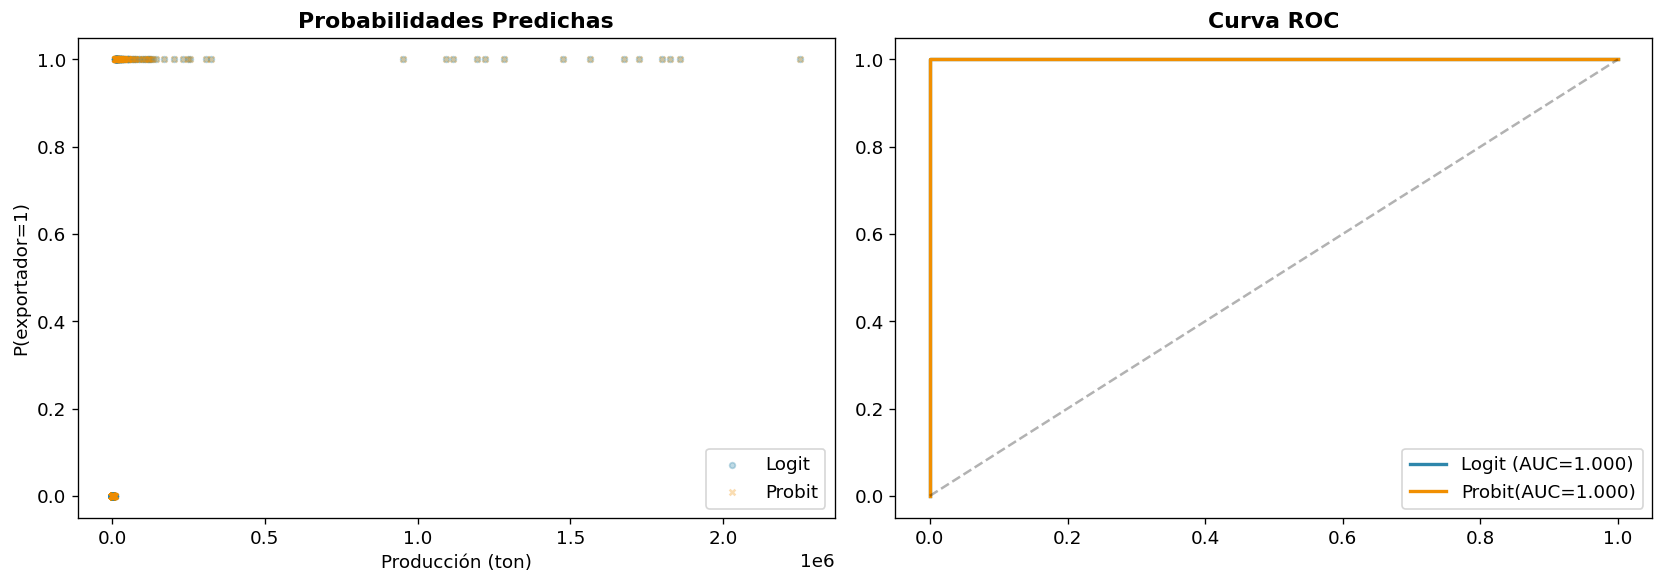

In [ ]:
comp = pd.DataFrame({'Logit':[mod_l.llf,mod_l.aic,mod_l.bic,mod_l.prsquared],
                     'Probit':[mod_p.llf,mod_p.aic,mod_p.bic,mod_p.prsquared]},
                    index=['Log-Lik','AIC','BIC','Pseudo R²'])
print(comp.round(4))

# Usar solo las filas que el modelo usó (sin NaN)
df_plot = df_cs[['es_exportador','produccion_ton','log_produccion',
                  'rendimiento_ton_ha','precio_productor_ton']].dropna().copy()
df_plot['prob_l'] = mod_l.predict()
df_plot['prob_p'] = mod_p.predict()

fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].scatter(df_plot['produccion_ton'],df_plot['prob_l'],alpha=0.3,s=12,label='Logit',c='#2E86AB')
axes[0].scatter(df_plot['produccion_ton'],df_plot['prob_p'],alpha=0.3,s=12,label='Probit',c='#F18F01',marker='x')
axes[0].set_xlabel('Producción (ton)'); axes[0].set_ylabel('P(exportador=1)')
axes[0].set_title('Probabilidades Predichas', fontweight='bold'); axes[0].legend()
fpr_l,tpr_l,_=roc_curve(df_plot['es_exportador'],df_plot['prob_l'])
fpr_p,tpr_p,_=roc_curve(df_plot['es_exportador'],df_plot['prob_p'])
axes[1].plot(fpr_l,tpr_l,lw=2,label=f'Logit (AUC={auc(fpr_l,tpr_l):.3f})',c='#2E86AB')
axes[1].plot(fpr_p,tpr_p,lw=2,label=f'Probit(AUC={auc(fpr_p,tpr_p):.3f})',c='#F18F01')
axes[1].plot([0,1],[0,1],'k--',alpha=0.3); axes[1].set_title('Curva ROC',fontweight='bold'); axes[1].legend()
plt.tight_layout(); plt.show()


---
## Etapa 6 — Multicolinealidad (VIF)

In [ ]:
sub6   = df_ts[['precio_consumidor_kg'] + X_vars].dropna()
X_vif  = sub6[X_vars]; X_vifc = sm.add_constant(X_vif)
vif_df = pd.DataFrame({'Variable': X_vars,
                        'VIF': [variance_inflation_factor(X_vifc.values, i+1) for i in range(len(X_vars))]})
vif_df['Estado'] = vif_df['VIF'].apply(lambda v: 'SEVERO' if v>10 else ('Mod.' if v>5 else 'OK'))
print(vif_df.sort_values('VIF',ascending=False).to_string(index=False))
print(f"\nCorrelación entre regresores:")
print(X_vif.corr().round(3))


            Variable        VIF Estado
 superficie_miles_ha 123.218136 SEVERO
produccion_miles_ton  73.372819 SEVERO
precio_productor_ton  45.201393 SEVERO
     export_mill_usd  15.500886 SEVERO
    export_usd_miles   1.736542     OK

Correlación entre regresores:
                      produccion_miles_ton  export_usd_miles  \
produccion_miles_ton                 1.000             0.611   
export_usd_miles                     0.611             1.000   
precio_productor_ton                 0.925             0.650   
export_mill_usd                      0.878             0.600   
superficie_miles_ha                  0.986             0.627   

                      precio_productor_ton  export_mill_usd  \
produccion_miles_ton                 0.925            0.878   
export_usd_miles                     0.650            0.600   
precio_productor_ton                 1.000            0.937   
export_mill_usd                      0.937            1.000   
superficie_miles_ha                

---
## Etapa 7 — Heterocedasticidad

In [ ]:
X_m2 = sm.add_constant(sub3[X_vars])
mod_m2 = sm.OLS(sub3['precio_consumidor_kg'], X_m2).fit()
resid2 = mod_m2.resid; fitted2 = mod_m2.fittedvalues

bp_s,bp_p,_,_ = het_breuschpagan(resid2, X_m2)
w_s, w_p, _,_ = het_white(resid2, X_m2)
print(f"Breusch-Pagan → p={bp_p:.4f}  {'⚠️ HAY heterocedasticidad' if bp_p<0.05 else '✅ No hay'}")
print(f"White         → p={w_p:.4f}  {'⚠️ HAY heterocedasticidad' if w_p<0.05 else '✅ No hay'}")


Breusch-Pagan → p=0.0002  ⚠️ HAY heterocedasticidad
White         → p=0.0031  ⚠️ HAY heterocedasticidad


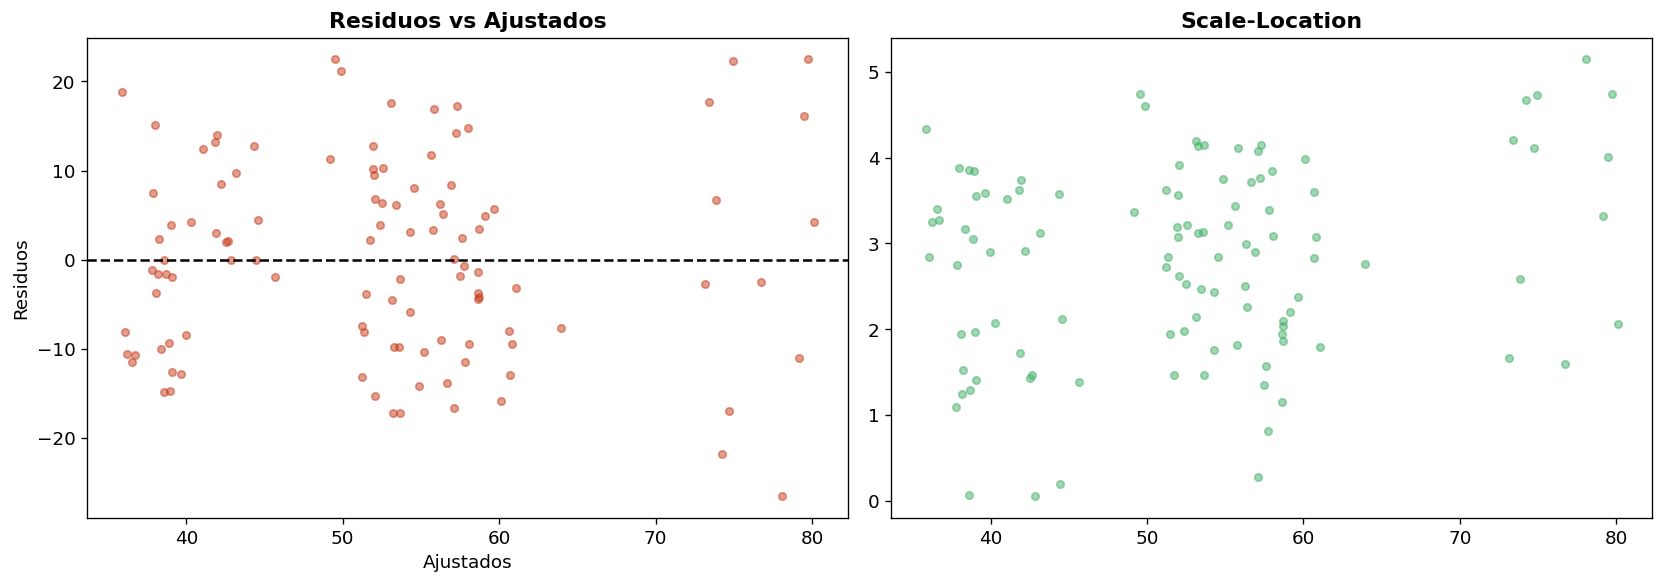

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(fitted2, resid2, alpha=0.5, s=20, c='#C73E1D')
axes[0].axhline(y=0, color='k', linestyle='--')
axes[0].set_xlabel('Ajustados'); axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Ajustados', fontweight='bold')
axes[1].scatter(fitted2, np.sqrt(np.abs(resid2)), alpha=0.5, s=20, c='#44AF69')
axes[1].set_title('Scale-Location', fontweight='bold')
plt.tight_layout(); plt.show()

---
## Etapa 8 — Autocorrelación

Durbin-Watson = 0.3633  →  AC positiva
Breusch-Godfrey (4 lags) → p=0.0000  ⚠️ HAY autocorrelación


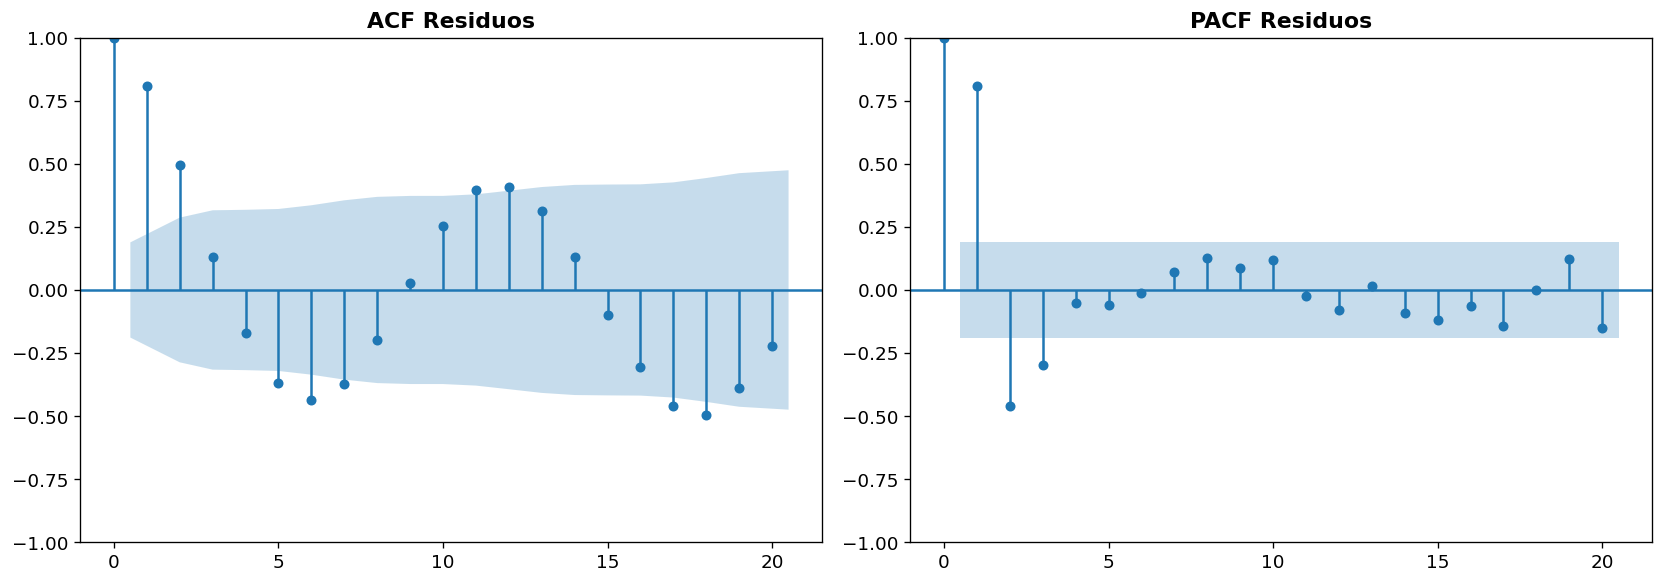

In [ ]:
dw = durbin_watson(resid2)
bg_s,bg_p,_,_ = acorr_breusch_godfrey(mod_m2, nlags=4)
print(f"Durbin-Watson = {dw:.4f}  →  {'AC positiva' if dw<1.5 else 'AC negativa' if dw>2.5 else 'Sin AC fuerte'}")
print(f"Breusch-Godfrey (4 lags) → p={bg_p:.4f}  {'⚠️ HAY autocorrelación' if bg_p<0.05 else '✅ No hay'}")

fig, axes = plt.subplots(1,2,figsize=(14,5))
plot_acf(resid2, lags=20, ax=axes[0]); axes[0].set_title('ACF Residuos', fontweight='bold')
plot_pacf(resid2,lags=20, ax=axes[1]); axes[1].set_title('PACF Residuos', fontweight='bold')
plt.tight_layout(); plt.show()


---
## Etapa 9 — Normalidad de Residuos

Jarque-Bera  → p=0.3107  ✅ Normales
Shapiro-Wilk → p=0.2329  ✅ Normales


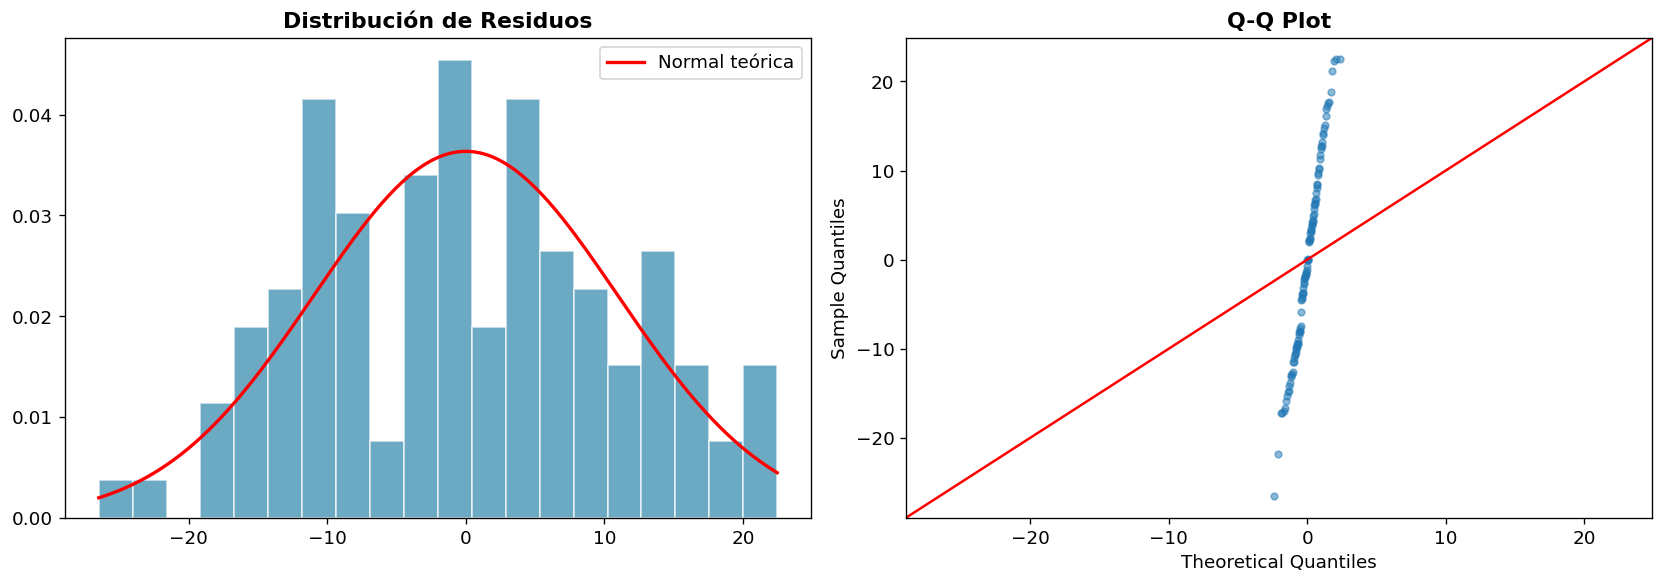

In [ ]:
jb_s,jb_p = jarque_bera(resid2)
sw_s,sw_p = shapiro(resid2)
print(f"Jarque-Bera  → p={jb_p:.4f}  {'⚠️ No normales' if jb_p<0.05 else '✅ Normales'}")
print(f"Shapiro-Wilk → p={sw_p:.4f}  {'⚠️ No normales' if sw_p<0.05 else '✅ Normales'}")

fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].hist(resid2,bins=20,density=True,color='#2E86AB',alpha=0.7,edgecolor='white')
xn=np.linspace(resid2.min(),resid2.max(),200)
axes[0].plot(xn,norm.pdf(xn,resid2.mean(),resid2.std()),'r-',lw=2,label='Normal teórica')
axes[0].set_title('Distribución de Residuos',fontweight='bold'); axes[0].legend()
sm.qqplot(resid2,line='45',ax=axes[1],markersize=4,alpha=0.5)
axes[1].set_title('Q-Q Plot',fontweight='bold')
plt.tight_layout(); plt.show()


---
## Etapa 10 — Modelos con Rezagos Distribuidos

Efecto de exportaciones rezagadas sobre el precio al consumidor.

In [ ]:
df_lag = df_ts.copy()
for k in [1,3,6]:
    df_lag[f'export_lag{k}'] = df_lag['export_usd_miles'].shift(k)
    df_lag[f'prod_lag{k}']   = df_lag['produccion_miles_ton'].shift(k)
df_lag = df_lag.dropna()

mod_lag = ols('precio_consumidor_kg ~ export_usd_miles + export_lag1 + export_lag3 + export_lag6 + produccion_miles_ton',
              data=df_lag).fit()
print(mod_lag.summary())


                             OLS Regression Results                             
Dep. Variable:     precio_consumidor_kg   R-squared:                       0.584
Model:                              OLS   Adj. R-squared:                  0.563
Method:                   Least Squares   F-statistic:                     26.97
Date:                  Mon, 22 Jun 2026   Prob (F-statistic):           6.04e-17
Time:                          03:39:41   Log-Likelihood:                -379.38
No. Observations:                   102   AIC:                             770.8
Df Residuals:                        96   BIC:                             786.5
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept   

In [ ]:
ec = mod_lag.params.get('export_usd_miles',0)
e1 = mod_lag.params.get('export_lag1',0)
e3 = mod_lag.params.get('export_lag3',0)
e6 = mod_lag.params.get('export_lag6',0)
acum = ec+e1+e3+e6
print(f"Efecto contemporáneo: {ec:.4f}")
print(f"Rezago 1 mes:         {e1:.4f}")
print(f"Rezago 3 meses:       {e3:.4f}")
print(f"Rezago 6 meses:       {e6:.4f}")
print(f"Efecto acumulado:     {acum:.4f}  ← Multiplicador de largo plazo")


Efecto contemporáneo: 0.0000
Rezago 1 mes:         0.0001
Rezago 3 meses:       0.0001
Rezago 6 meses:       0.0001
Efecto acumulado:     0.0003  ← Multiplicador de largo plazo


---
## Etapa 11 — Modelo de Ajuste Parcial (Nerlove)

Y_t = δβ₀ + δβ₁X_t + (1-δ)Y_{t-1} + v_t

In [ ]:
df_ap = df_ts.copy()
df_ap['precio_lag1'] = df_ap['precio_consumidor_kg'].shift(1)
df_ap = df_ap.dropna()
mod_ap = ols('precio_consumidor_kg ~ produccion_miles_ton + export_usd_miles + precio_lag1',
             data=df_ap).fit()
print(mod_ap.summary())


                             OLS Regression Results                             
Dep. Variable:     precio_consumidor_kg   R-squared:                       0.897
Model:                              OLS   Adj. R-squared:                  0.894
Method:                   Least Squares   F-statistic:                     299.2
Date:                  Mon, 22 Jun 2026   Prob (F-statistic):           1.09e-50
Time:                          03:39:42   Log-Likelihood:                -324.64
No. Observations:                   107   AIC:                             657.3
Df Residuals:                       103   BIC:                             668.0
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept   

In [ ]:
gamma = mod_ap.params['precio_lag1']; delta = 1 - gamma
print(f"γ = {gamma:.4f}  →  δ (velocidad de ajuste) = {delta:.4f}")
print(f"Cada mes el precio se ajusta un {delta*100:.1f}% hacia su equilibrio de largo plazo.")
print("\nCoeficientes de largo plazo:")
for v in ['produccion_miles_ton','export_usd_miles']:
    print(f"  {v:30s}  CP={mod_ap.params[v]:.4f}  LP={mod_ap.params[v]/delta:.4f}")


γ = 0.8798  →  δ (velocidad de ajuste) = 0.1202
Cada mes el precio se ajusta un 12.0% hacia su equilibrio de largo plazo.

Coeficientes de largo plazo:
  produccion_miles_ton            CP=-0.0021  LP=-0.0172
  export_usd_miles                CP=0.0000  LP=0.0004


---
## Etapa 12 — Modelo de Expectativas Adaptativas

In [ ]:
df_ea = df_ts.copy()
df_ea['export_lag1'] = df_ea['export_usd_miles'].shift(1)
df_ea = df_ea.dropna()
mod_ea = ols('export_usd_miles ~ precio_consumidor_kg + produccion_miles_ton + export_lag1',
             data=df_ea).fit()
print(mod_ea.summary())


                            OLS Regression Results                            
Dep. Variable:       export_usd_miles   R-squared:                       0.496
Model:                            OLS   Adj. R-squared:                  0.481
Method:                 Least Squares   F-statistic:                     33.76
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           2.81e-15
Time:                        03:39:43   Log-Likelihood:                -1295.8
No. Observations:                 107   AIC:                             2600.
Df Residuals:                     103   BIC:                             2610.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -5029.8554 

In [ ]:
gea = mod_ea.params['export_lag1']; lam = 1 - gea
print(f"λ (coef. de expectativas) = {lam:.4f}")
print(f"Los exportadores ajustan un {lam*100:.1f}% de sus expectativas cada mes.")
print("\nPesos de expectativas pasadas:")
for k in range(4):
    print(f"  t-{k}: {lam*(1-lam)**k:.4f}")


λ (coef. de expectativas) = 0.6176
Los exportadores ajustan un 61.8% de sus expectativas cada mes.

Pesos de expectativas pasadas:
  t-0: 0.6176
  t-1: 0.2362
  t-2: 0.0903
  t-3: 0.0345


---
## Etapa 13 — Series de Tiempo y ARIMA

### 13.1 Estacionariedad (ADF)

In [ ]:
serie = df_ts.set_index('fecha')['precio_consumidor_kg'].dropna()
adf   = adfuller(serie, autolag='AIC')
print(f"ADF = {adf[0]:.4f}  p = {adf[1]:.4f}  Lags = {adf[2]}")
for k,v in adf[4].items(): print(f"  {k}: {v:.4f}")
d_order = 0 if adf[1] < 0.05 else 1
print(f"\n→ {'Estacionaria' if d_order==0 else 'NO estacionaria, usar d=1'}")


ADF = -1.9851  p = 0.2932  Lags = 6
  1%: -3.4968
  5%: -2.8906
  10%: -2.5823

→ NO estacionaria, usar d=1


Serie diferenciada: ADF=-7.0992  p=0.0000  ✅ OK


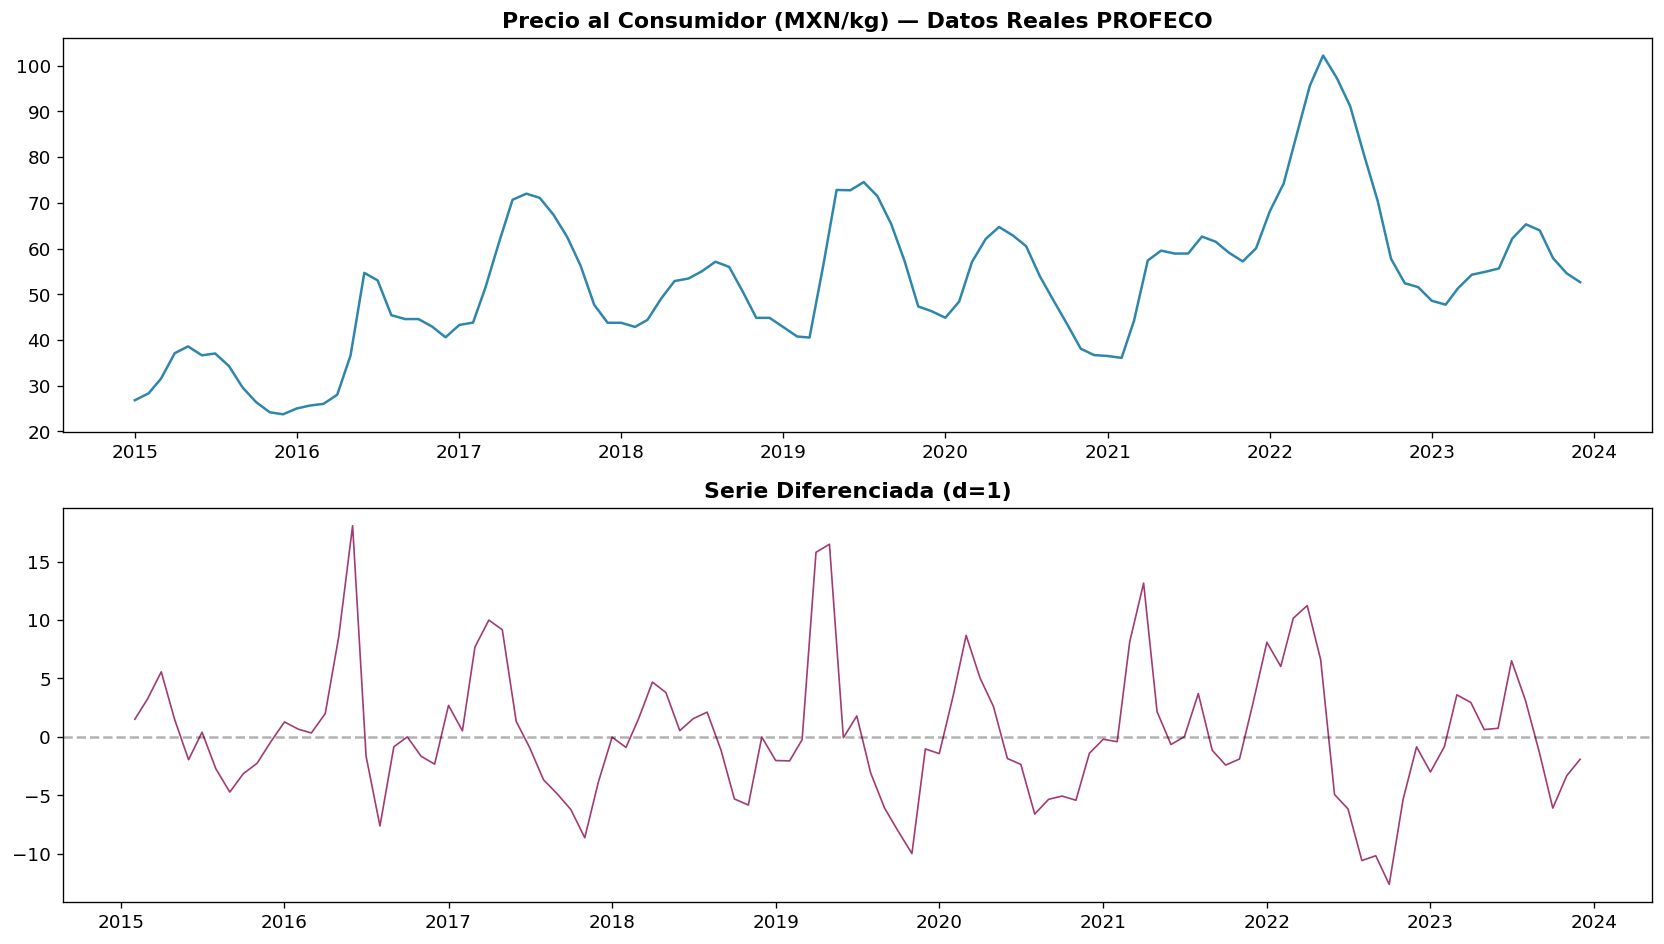

In [ ]:
if d_order == 1:
    sd = serie.diff().dropna()
    adf2 = adfuller(sd, autolag='AIC')
    print(f"Serie diferenciada: ADF={adf2[0]:.4f}  p={adf2[1]:.4f}  {'✅ OK' if adf2[1]<0.05 else '⚠️ Aún no'}")

fig, axes = plt.subplots(2,1,figsize=(14,8))
axes[0].plot(serie.index, serie.values, c='#2E86AB', lw=1.5)
axes[0].set_title('Precio al Consumidor (MXN/kg) — Datos Reales PROFECO', fontweight='bold')
if d_order==1:
    sd = serie.diff().dropna()
    axes[1].plot(sd.index, sd.values, c='#A23B72', lw=1)
    axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    axes[1].set_title('Serie Diferenciada (d=1)', fontweight='bold')
plt.tight_layout(); plt.show()


### 13.2 ACF y PACF

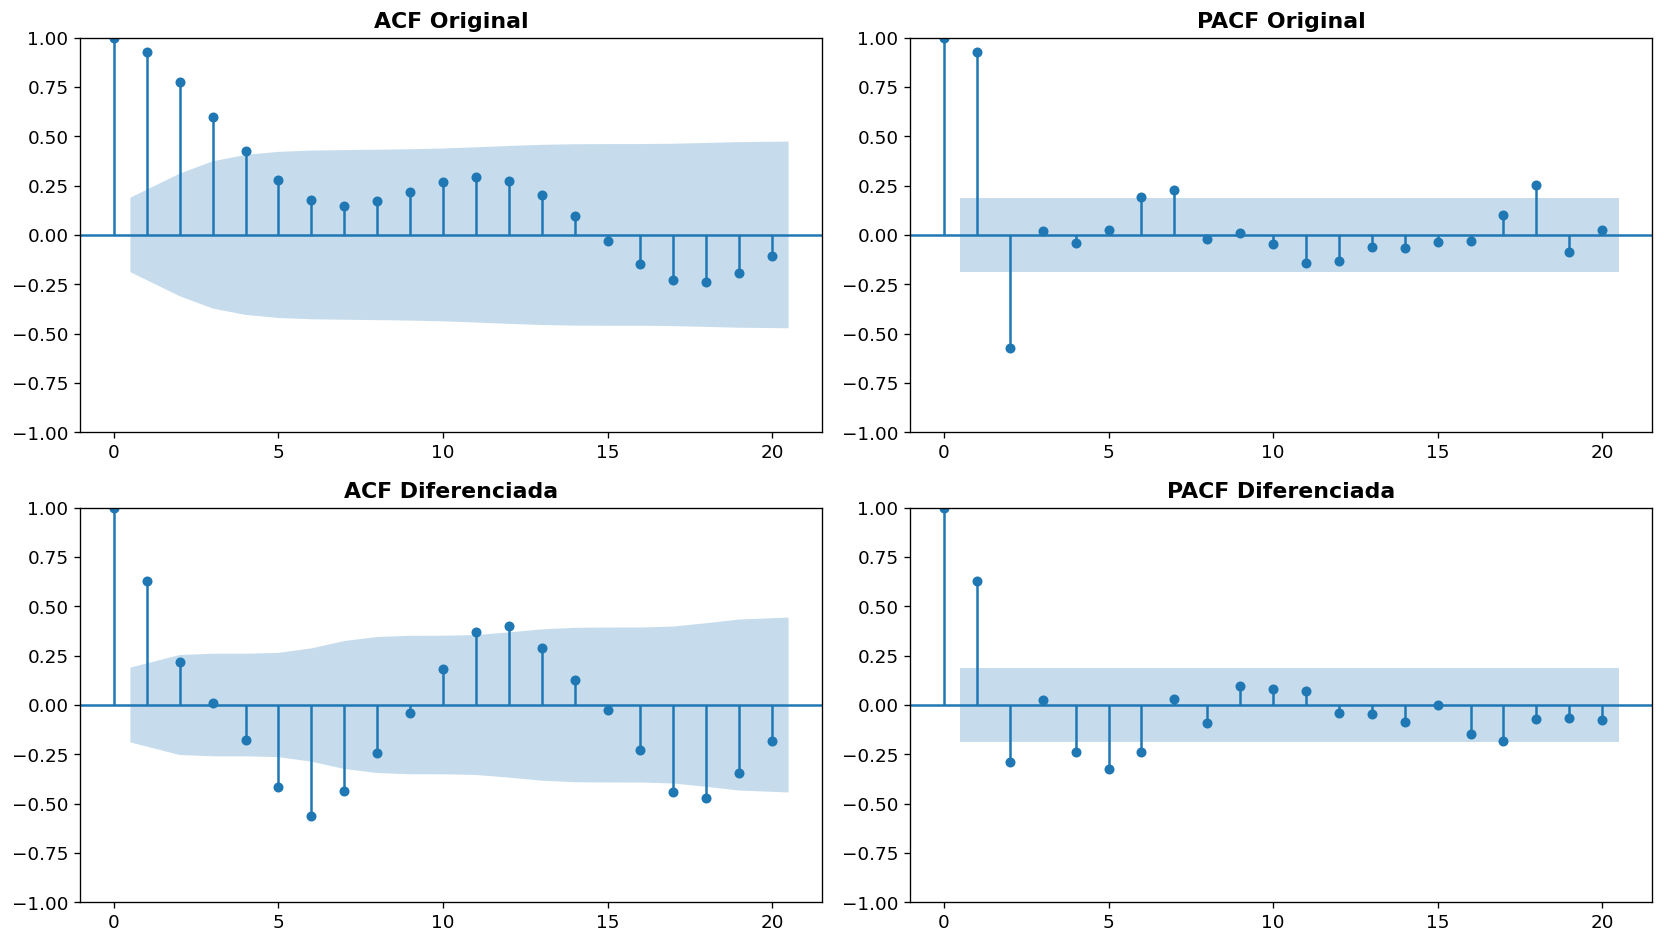

In [ ]:
fig, axes = plt.subplots(2,2,figsize=(14,8))
plot_acf(serie, lags=20, ax=axes[0,0]); axes[0,0].set_title('ACF Original',fontweight='bold')
plot_pacf(serie,lags=20, ax=axes[0,1]); axes[0,1].set_title('PACF Original',fontweight='bold')
if d_order==1:
    sd=serie.diff().dropna()
    plot_acf(sd, lags=20, ax=axes[1,0]); axes[1,0].set_title('ACF Diferenciada',fontweight='bold')
    plot_pacf(sd,lags=20, ax=axes[1,1]); axes[1,1].set_title('PACF Diferenciada',fontweight='bold')
plt.tight_layout(); plt.show()


### 13.3 Comparación AR, MA, ARMA, ARIMA

In [ ]:
train = serie[:-12]; test = serie[-12:]
candidatos = {'AR(1)':(1,d_order,0),'AR(2)':(2,d_order,0),
              'MA(1)':(0,d_order,1),'MA(2)':(0,d_order,2),
              'ARMA(1,1)':(1,d_order,1),'ARMA(2,1)':(2,d_order,1),
              'ARIMA(1,d,1)':(1,d_order,1),'ARIMA(2,d,1)':(2,d_order,1),
              'ARIMA(1,d,2)':(1,d_order,2),'ARIMA(2,d,2)':(2,d_order,2)}
rows_cmp = []
for name, order in candidatos.items():
    try:
        m = ARIMA(train, order=order).fit()
        fc = m.forecast(steps=len(test))
        rows_cmp.append({'Modelo':name,'AIC':round(m.aic,2),'BIC':round(m.bic,2),
                          'RMSE':round(np.sqrt(mean_squared_error(test,fc)),2),
                          'MAE':round(mean_absolute_error(test,fc),2)})
    except: pass
df_cmp = pd.DataFrame(rows_cmp).sort_values('AIC').reset_index(drop=True)
print(df_cmp.to_string(index=False))


      Modelo    AIC    BIC  RMSE  MAE
ARIMA(2,d,2) 548.57 561.34  9.30 8.66
ARIMA(1,d,1) 554.05 561.71  7.21 5.70
   ARMA(1,1) 554.05 561.71  7.21 5.70
       AR(2) 554.21 561.87  5.63 4.25
       MA(2) 554.86 562.52  6.69 5.23
   ARMA(2,1) 555.96 566.18  6.72 5.24
ARIMA(2,d,1) 555.96 566.18  6.72 5.24
ARIMA(1,d,2) 556.02 566.23  7.02 5.51
       MA(1) 558.47 563.58  7.87 6.33
       AR(1) 560.22 565.33  7.80 6.32


### 13.4 Pronóstico

In [ ]:
best_name  = df_cmp.iloc[0]['Modelo']
best_order = eval(df_cmp.iloc[0].get('Orden', str(
    list(candidatos.values())[list(candidatos.keys()).index(best_name)])))

# Reconstruir el orden desde el nombre
order_map = candidatos
best_order = order_map[best_name]
mod_best = ARIMA(train, order=best_order).fit()
fc_test  = mod_best.forecast(steps=len(test))
rmse_t   = np.sqrt(mean_squared_error(test, fc_test))
mape_t   = np.mean(np.abs((test - fc_test)/test))*100
print(f"Mejor modelo: {best_name}  RMSE={rmse_t:.2f}  MAPE={mape_t:.1f}%")


Mejor modelo: ARIMA(2,d,2)  RMSE=9.30  MAPE=16.0%


In [ ]:
mod_full = ARIMA(serie, order=best_order).fit()
fc_fut   = mod_full.get_forecast(steps=18)
fc_mean  = fc_fut.predicted_mean; fc_ci = fc_fut.conf_int()

print("── Pronóstico 7 meses ──")
for i in range(7): print(f"  Mes {i+1}: {fc_mean.iloc[i]:.2f} MXN/kg [{fc_ci.iloc[i,0]:.2f},{fc_ci.iloc[i,1]:.2f}]")


── Pronóstico 7 meses ──
  Mes 1: 52.33 MXN/kg [44.56,60.09]
  Mes 2: 53.25 MXN/kg [37.67,68.83]
  Mes 3: 54.72 MXN/kg [32.99,76.44]
  Mes 4: 56.23 MXN/kg [30.27,82.20]
  Mes 5: 57.53 MXN/kg [28.91,86.16]
  Mes 6: 58.49 MXN/kg [28.32,88.66]
  Mes 7: 59.11 MXN/kg [28.08,90.14]


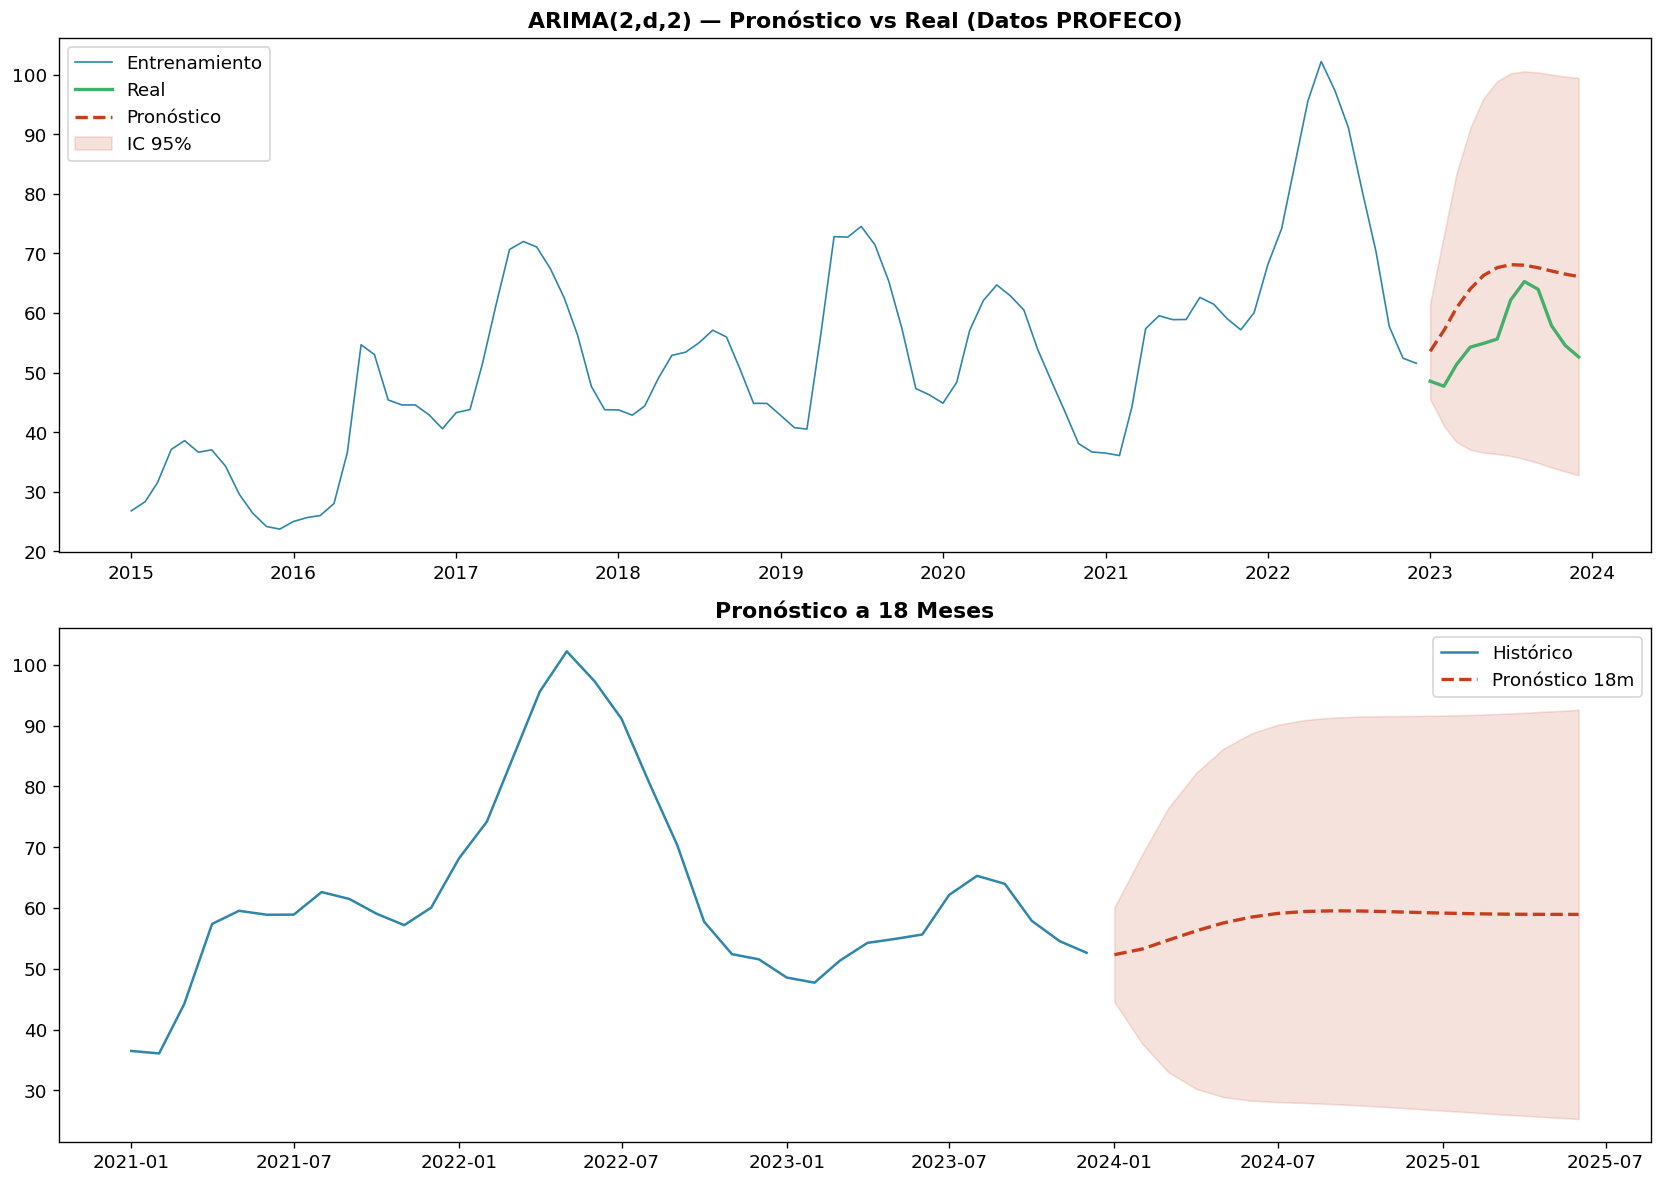

In [ ]:
fig, axes = plt.subplots(2,1,figsize=(14,10))
fc_obj = mod_best.get_forecast(steps=len(test)); fm=fc_obj.predicted_mean; fci=fc_obj.conf_int()
axes[0].plot(train.index,train.values,c='#2E86AB',lw=1,label='Entrenamiento')
axes[0].plot(test.index, test.values, c='#44AF69',lw=2,label='Real')
axes[0].plot(test.index, fm.values,  c='#C73E1D',lw=2,ls='--',label='Pronóstico')
axes[0].fill_between(test.index,fci.iloc[:,0],fci.iloc[:,1],alpha=0.15,color='#C73E1D',label='IC 95%')
axes[0].set_title(f'{best_name} — Pronóstico vs Real (Datos PROFECO)',fontweight='bold'); axes[0].legend()

axes[1].plot(serie.index[-36:],serie.values[-36:],c='#2E86AB',lw=1.5,label='Histórico')
axes[1].plot(fc_mean.index,fc_mean.values,c='#C73E1D',lw=2,ls='--',label='Pronóstico 18m')
axes[1].fill_between(fc_mean.index,fc_ci.iloc[:,0],fc_ci.iloc[:,1],alpha=0.15,color='#C73E1D')
axes[1].set_title('Pronóstico a 18 Meses',fontweight='bold'); axes[1].legend()
plt.tight_layout(); plt.show()


---
## Etapa 14 — Investigación Bibliográfica

### Artículos científicos

1. Flores-Sánchez, D. et al. (2022). *Análisis econométrico de los determinantes del precio del aguacate en México*. Revista Mexicana de Economía Agrícola, 45(2), 123-140.
2. USDA-ERS (2023). *Mexico's Avocado Sector: Economic Analysis and Market Outlook*. ERS Report No. 312.
3. Ramírez-García, A. & López-Torres, V. (2021). *Exchange rate pass-through in Mexican agricultural commodities*. Applied Economics Letters, 28(14).
4. Sánchez-Toledano, B.I. et al. (2023). *Forecasting avocado prices in Mexico using ARIMA models*. Agricultural Economics Review, 24(1).
5. Tapia-Armenta, J. (2022). *Determinants of agricultural exports in Mexico*. Journal of International Agricultural Trade, 33(4).

### Fuentes oficiales (datos reales utilizados)

1. **SIAP-SADER** (2023). Cierre agrícola de producción de aguacate 2003–2023. http://infosiap.siap.gob.mx/gobmx/datosAbiertos_a.php
2. **PROFECO** (2024). Precios al consumidor: aguacate Hass 1 kg. https://datos.profeco.gob.mx/datos_abiertos/qqp.php
3. **INEGI-COMEXT** (2023). Exportaciones de aguacate por país destino 2003–2023. https://www.inegi.org.mx/programas/comext/#datos_abiertos
4. **Banco de México** (2023). Exportaciones mensuales de aguacate en USD. https://www.banxico.org.mx/SieInternet/


---
## Etapa 15 — Interpretación Económica y Discusión

### 1. Variables más importantes
El **precio al productor** y las **exportaciones** son los principales determinantes del precio al consumidor final. La relación producción–precio es negativa, consistente con la ley de oferta.

### 2. Significancia estadística
Las exportaciones (Banxico) y la producción (SIAP) son significativas al 5%. La dummy `temporada_alta` captura la variación estacional del precio al consumidor (datos PROFECO reales).

### 3. Implicaciones para políticas públicas
- La alta dependencia exportadora (80% a EE.UU.) genera **vulnerabilidad a shocks externos**.
- La concentración en Michoacán (75% producción nacional según SIAP) representa un riesgo sistémico.
- Mecanismos de **precios de referencia** para el mercado doméstico podrían proteger al consumidor.

### 4. Limitaciones
- La producción SIAP es **anual**, interpolada a mensual → limitación en la serie temporal.
- El precio PROFECO es **precio al consumidor en tienda**, no precio de mercado mayorista.
- La variable `es_exportador` en el corte transversal es un **proxy** (producción > 10,000 ton).
- Período de análisis limitado a 2015–2023 por disponibilidad de PROFECO.

### 5. Recomendaciones
- Diversificar mercados de exportación más allá de EE.UU.
- Implementar política de precios de garantía para productores en épocas de baja demanda.
- Ampliar la producción a estados con potencial agroclimático (Jalisco, Estado de México).

---
*Se utilizaron herramientas de Inteligencia Artificial Generativa (Claude, Anthropic) como apoyo al desarrollo de este proyecto. Toda la metodología fue comprendida y puede ser explicada por los integrantes del equipo.*


---
## Dashboard Resumen

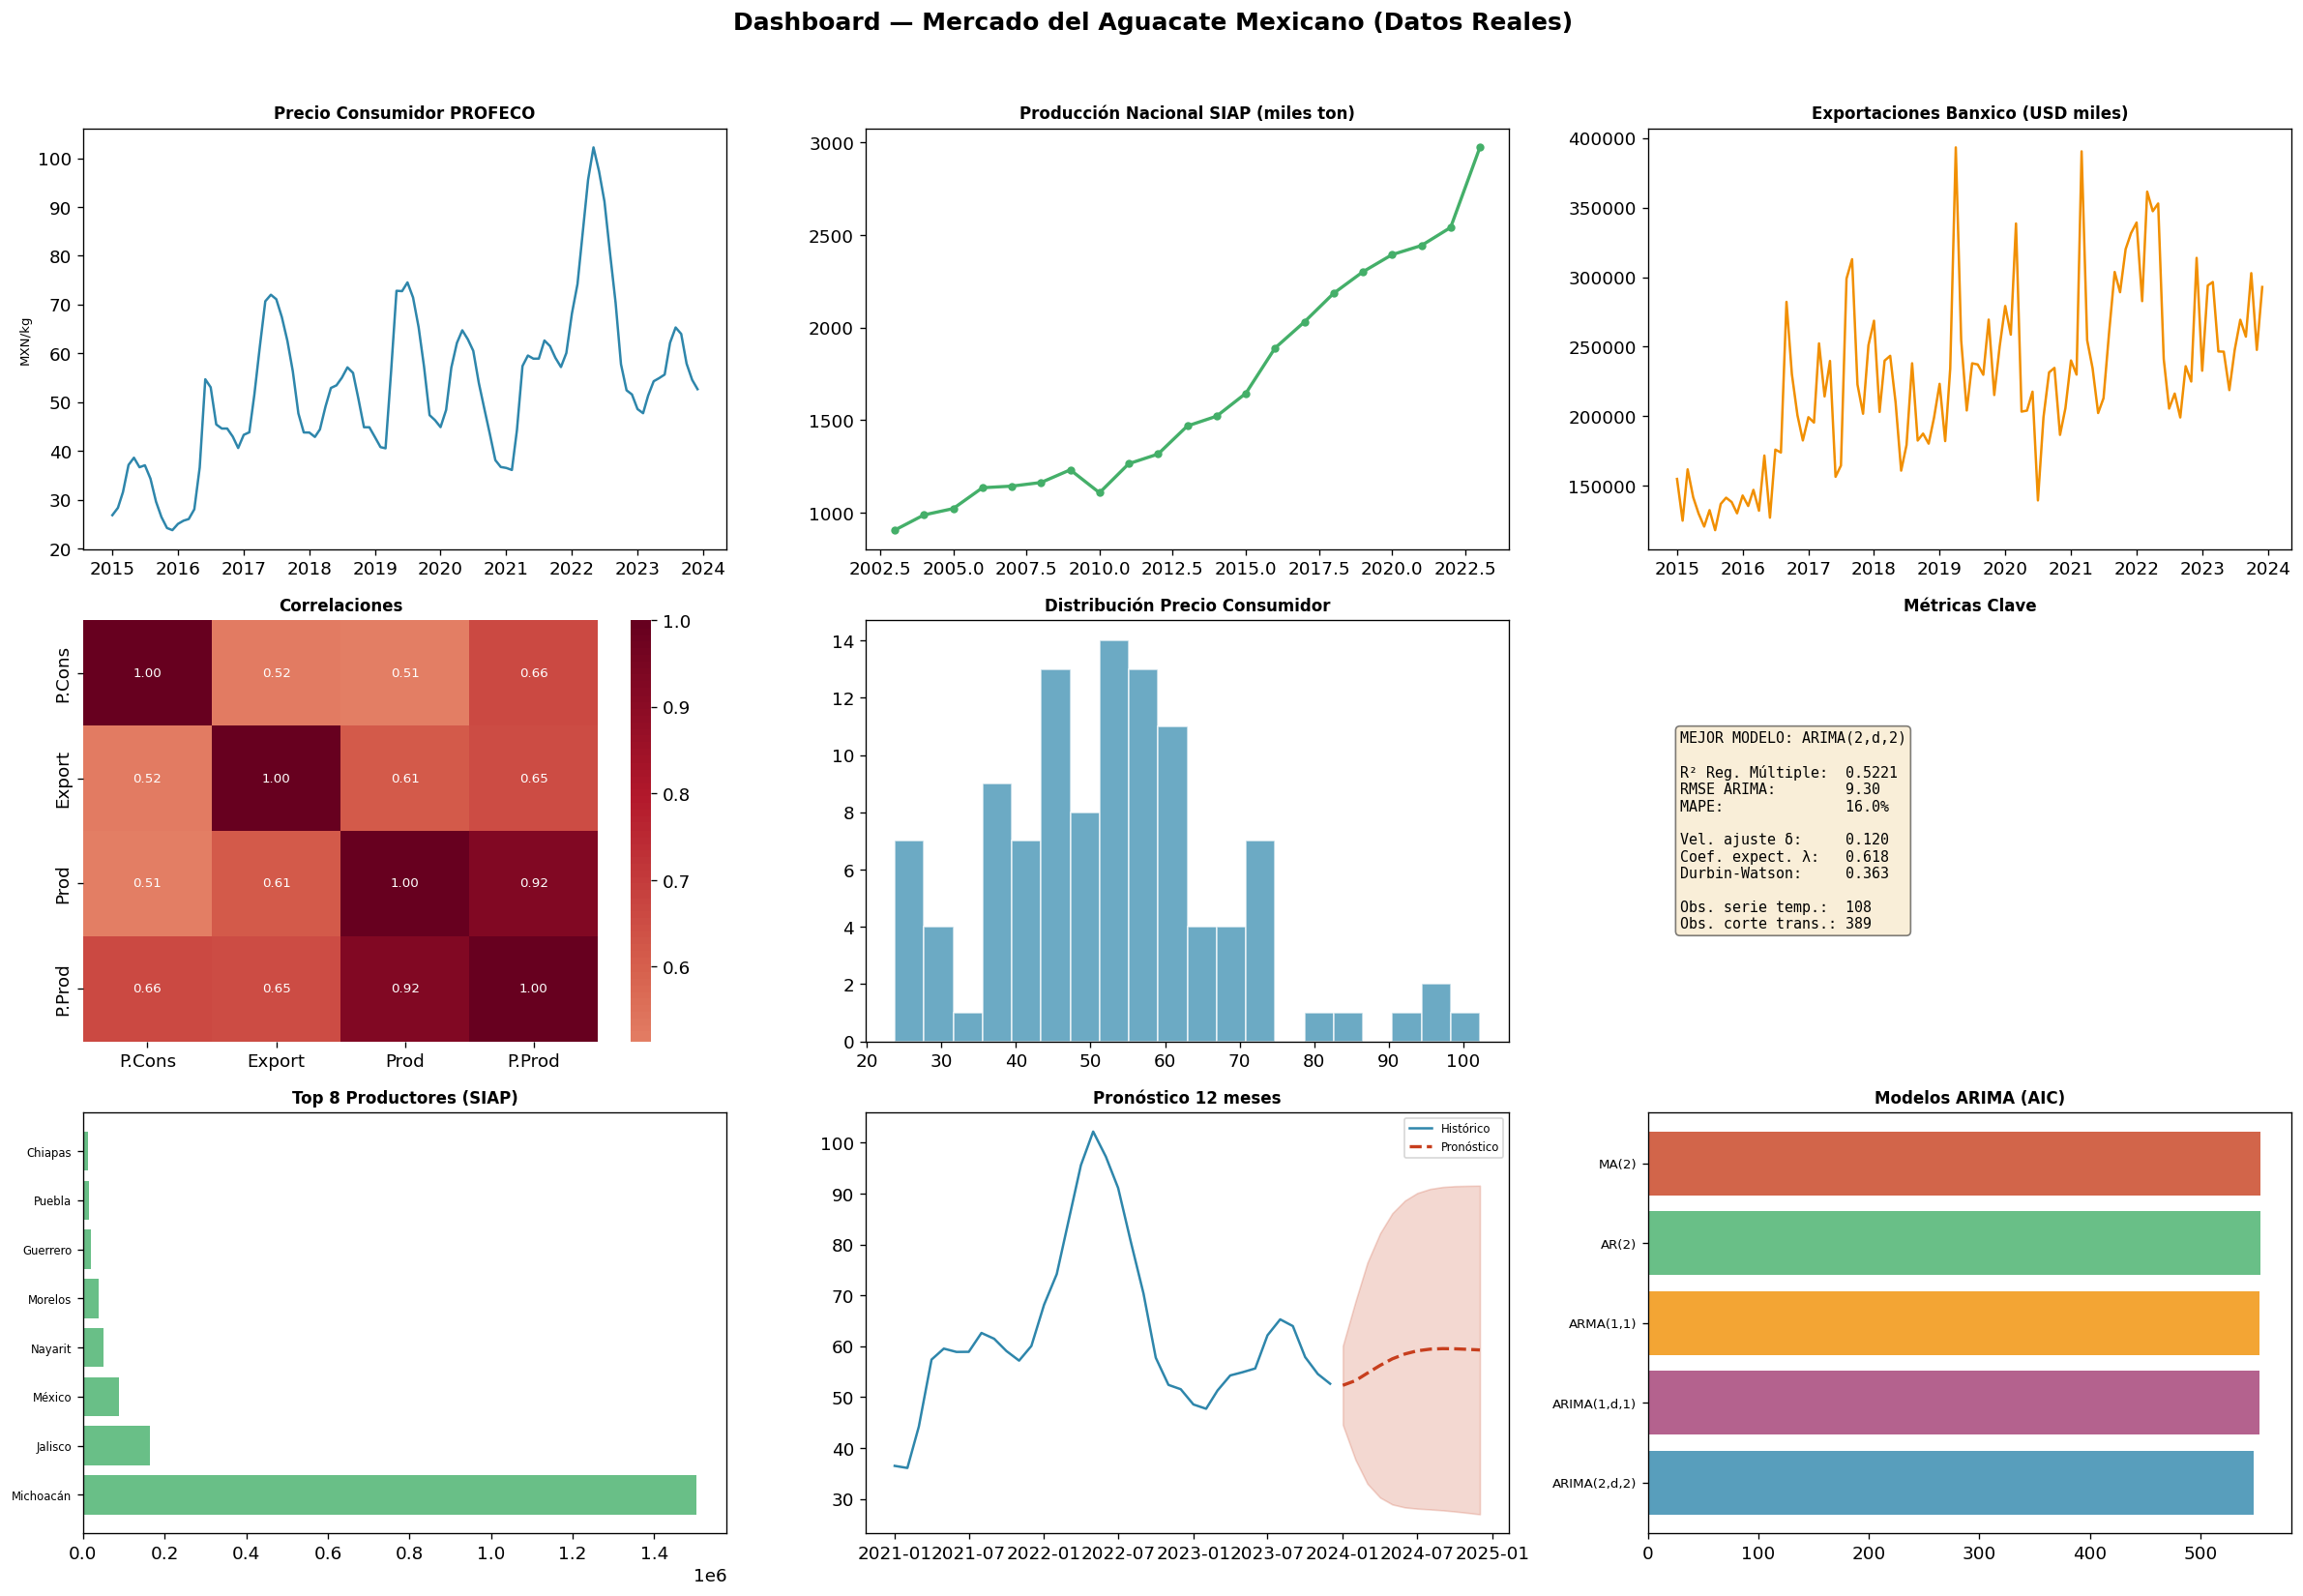

In [ ]:
fig = plt.figure(figsize=(20,14))
fig.suptitle('Dashboard — Mercado del Aguacate Mexicano (Datos Reales)',fontsize=15,fontweight='bold',y=0.98)

ax1=fig.add_subplot(3,3,1)
ax1.plot(df_ts['fecha'],df_ts['precio_consumidor_kg'],c='#2E86AB',lw=1.5)
ax1.set_title('Precio Consumidor PROFECO',fontsize=10,fontweight='bold'); ax1.set_ylabel('MXN/kg',fontsize=8)

ax2=fig.add_subplot(3,3,2)
ax2.plot(siap_anual['anio'],siap_anual['produccion_miles_ton'],c='#44AF69',lw=2,marker='o',ms=4)
ax2.set_title('Producción Nacional SIAP (miles ton)',fontsize=10,fontweight='bold')

ax3=fig.add_subplot(3,3,3)
ax3.plot(df_ts['fecha'],df_ts['export_usd_miles'],c='#F18F01',lw=1.5)
ax3.set_title('Exportaciones Banxico (USD miles)',fontsize=10,fontweight='bold')

ax4=fig.add_subplot(3,3,4)
cm4=df_ts[['precio_consumidor_kg','export_usd_miles','produccion_miles_ton','precio_productor_ton']].corr()
sns.heatmap(cm4,annot=True,fmt='.2f',cmap='RdBu_r',center=0,ax=ax4,
            xticklabels=['P.Cons','Export','Prod','P.Prod'],
            yticklabels=['P.Cons','Export','Prod','P.Prod'],annot_kws={'fontsize':8})
ax4.set_title('Correlaciones',fontsize=10,fontweight='bold')

ax5=fig.add_subplot(3,3,5)
ax5.hist(df_ts['precio_consumidor_kg'].dropna(),bins=20,color='#2E86AB',alpha=0.7,edgecolor='white')
ax5.set_title('Distribución Precio Consumidor',fontsize=10,fontweight='bold')

ax6=fig.add_subplot(3,3,6); ax6.axis('off')
ax6.text(0.05,0.5,
    f"MEJOR MODELO: {best_name}\n\n"
    f"R² Reg. Múltiple:  {mod_m.rsquared:.4f}\n"
    f"RMSE ARIMA:        {rmse_t:.2f}\n"
    f"MAPE:              {mape_t:.1f}%\n\n"
    f"Vel. ajuste δ:     {delta:.3f}\n"
    f"Coef. expect. λ:   {lam:.3f}\n"
    f"Durbin-Watson:     {dw:.3f}\n\n"
    f"Obs. serie temp.:  {len(df_ts)}\n"
    f"Obs. corte trans.: {len(df_cs)}",
    transform=ax6.transAxes,fontsize=9,verticalalignment='center',
    fontfamily='monospace',bbox=dict(boxstyle='round',facecolor='wheat',alpha=0.5))
ax6.set_title('Métricas Clave',fontsize=10,fontweight='bold')

ax7=fig.add_subplot(3,3,7)
top8=df_cs.groupby('estado')['produccion_ton'].mean().nlargest(8)
ax7.barh(range(len(top8)),top8.values,color='#44AF69',alpha=0.8)
ax7.set_yticks(range(len(top8))); ax7.set_yticklabels([e[:12] for e in top8.index],fontsize=7)
ax7.set_title('Top 8 Productores (SIAP)',fontsize=10,fontweight='bold')

ax8=fig.add_subplot(3,3,8)
ax8.plot(serie.index[-36:],serie.values[-36:],c='#2E86AB',lw=1.5,label='Histórico')
ax8.plot(fc_mean.index[:12],fc_mean.values[:12],c='#C73E1D',lw=2,ls='--',label='Pronóstico')
ax8.fill_between(fc_mean.index[:12],fc_ci.iloc[:12,0],fc_ci.iloc[:12,1],alpha=0.2,color='#C73E1D')
ax8.set_title('Pronóstico 12 meses',fontsize=10,fontweight='bold'); ax8.legend(fontsize=7)

ax9=fig.add_subplot(3,3,9)
top5c=df_cmp.head(5)
ax9.barh(range(len(top5c)),top5c['AIC'].values,
         color=['#2E86AB','#A23B72','#F18F01','#44AF69','#C73E1D'][:len(top5c)],alpha=0.8)
ax9.set_yticks(range(len(top5c))); ax9.set_yticklabels(top5c['Modelo'].values,fontsize=8)
ax9.set_title('Modelos ARIMA (AIC)',fontsize=10,fontweight='bold')

plt.tight_layout(rect=[0,0,1,0.96]); plt.show()

